In [1]:
from icecube import dataclasses, dataio, icetray
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import time
import scipy.constants as spc
from icecube.phys_services import I3Calculator
from scipy.stats import ks_2samp
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter

In [2]:
params = {'figure.figsize': (7, 7*0.618),
          'legend.fontsize': 14,
          'axes.labelsize': 16,
          'axes.titlesize': 16,
          'xtick.labelsize': 16,
          'ytick.labelsize': 16}
plt.rcParams.update(params)

In [3]:
filelist = sorted(glob('/data/user/akatil/electron_neutrino/for_real/dataset_complete/enriched_all_with_beta/upgrade_genie_level4_queso_*_000*.i3.zst'))
beta1_arr_all = []
median_arr_all = []
reco_energy_all = []
reco_zen_all = []
weight_all = []
weight_no_osc_all = []
pid_all = []
daughter_type_all = []

count = 0
for file in filelist:
    count += 1
    if count % 50 == 0:
        print(count)
    infile=dataio.I3File(file)
    while(infile.more()):
        frame = infile.pop_frame()
        if frame.Stop == icetray.I3Frame.Physics:
            
            mctree = frame["I3MCTree"]
            primary = mctree.primaries

            daughter = dataclasses.I3MCTree.first_child(mctree, primary[0].id)

            #if daughter.type == 11:

            beta1_arr_all.append(frame['Beta1'].value)
            median_arr_all.append(frame['median_angle'].value)

            reco_energy_all.append(frame["graphnet_dynedge_energy_reconstruction_energy_pred"].value)
            x = frame['graphnet_dynedge_direction_reconstruction_dir_x_pred'].value
            y = frame['graphnet_dynedge_direction_reconstruction_dir_y_pred'].value
            z = frame['graphnet_dynedge_direction_reconstruction_dir_z_pred'].value
            rho = np.sqrt(x**2+y**2)

            reco_zeniths = np.arctan2(rho,z)

            reco_zen_all.append(np.cos(reco_zeniths))

            pid_all.append(frame['graphnet_dynedge_track_classification_track_pred'].value)

            daughter_type_all.append(daughter.type)

            if daughter.type == -15 and daughter.type == -16:
                weight_all.append(frame["I3MCWeightDict"]["weight"]/400)
                weight_no_osc_all.append(frame["I3MCWeightDict"]["weight_no_osc"]/400)
            elif daughter.type == -11 and daughter.type == -12:
                weight_all.append(frame["I3MCWeightDict"]["weight"]/500)
                weight_no_osc_all.append(frame["I3MCWeightDict"]["weight_no_osc"]/500)
            else:
                weight_all.append(frame["I3MCWeightDict"]["weight"]/1000)
                weight_no_osc_all.append(frame["I3MCWeightDict"]["weight_no_osc"]/1000)

50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
2050
2100
2150
2200
2250
2300
2350
2400
2450
2500
2550
2600
2650
2700
2750
2800
2850
2900
2950
3000
3050
3100
3150
3200
3250
3300
3350
3400
3450
3500
3550
3600
3650
3700
3750
3800
3850
3900
3950
4000
4050
4100
4150
4200
4250
4300
4350
4400
4450
4500
4550
4600
4650
4700
4750
4800
4850


In [40]:
beta1_arr_all = np.array(beta1_arr_all)
ang_arr_all = np.array(median_arr_all)
reco_energy_all = np.array(reco_energy_all)
reco_zen_all = np.array(reco_zen_all)
weight_all = np.array(weight_all)
weight_no_osc_all = np.array(weight_no_osc_all)
pid_all = np.array(pid_all)
daughter_type_all = np.array(daughter_type_all)

nue_boolean_all = (daughter_type_all == 11) | (daughter_type_all == -11)
numu_boolean_all = (daughter_type_all == 13) | (daughter_type_all == -13)
nutau_boolean_all = (daughter_type_all == 15) | (daughter_type_all == -15)
nc_boolean_all = (daughter_type_all == 12) | (daughter_type_all == -12) | (daughter_type_all == 14) | (daughter_type_all == -14) | (daughter_type_all == 16) | (daughter_type_all == -16)

enrich_boolean_all = (beta1_arr_all >= 0) & (beta1_arr_all <= 0.0002) & (ang_arr_all >= 0.62) & (ang_arr_all <= 0.77) & (pid_all <= 0.2) #& (reco_zen_all <= 0) #& 

#entriched selection, ideally should be selecting more of CC nue
beta1_arr = beta1_arr_all[enrich_boolean_all]
ang_arr = ang_arr_all[enrich_boolean_all]
reco_energy = reco_energy_all[enrich_boolean_all]
reco_zen = reco_zen_all[enrich_boolean_all]
weight = weight_all[enrich_boolean_all]
weight_no_osc = weight_no_osc_all[enrich_boolean_all]
pid = pid_all[enrich_boolean_all]
daughter_type = daughter_type_all[enrich_boolean_all]

nue_boolean = (daughter_type == 11) | (daughter_type == -11)
numu_boolean = (daughter_type == 13) | (daughter_type == -13)
nutau_boolean = (daughter_type == 15) | (daughter_type == -15)
nc_boolean = (daughter_type == 12) | (daughter_type == -12) | (daughter_type == 14) | (daughter_type == -14) | (daughter_type == 16) | (daughter_type == -16)

In [41]:
np.sum(weight[nue_boolean])*100/np.sum(weight_all[nue_boolean_all]), np.sum(weight[numu_boolean])*100/np.sum(weight_all[numu_boolean_all]), np.sum(weight[nutau_boolean])*100/np.sum(weight_all[nutau_boolean_all]), np.sum(weight[nc_boolean])*100/np.sum(weight_all[nc_boolean_all])

(1.1280401137683296, 0.2893397127161269, 3.426409055772921, 1.3599168786656846)

In [42]:
np.sum(weight_all[nue_boolean_all])*60*60*24*365 + np.sum(weight_all[numu_boolean_all])*60*60*24*365 + np.sum(weight_all[nutau_boolean_all])*60*60*24*365 + np.sum(weight_all[nc_boolean_all])*60*60*24*365

800337.259456323

In [43]:
np.sum(weight[nue_boolean])*60*60*24*365 + np.sum(weight[numu_boolean])*60*60*24*365 + np.sum(weight[nutau_boolean])*60*60*24*365 + np.sum(weight[nc_boolean])

4505.06429819125

In [44]:
def make_1D_hist_comparing_to_nue(arr, nue_bool, numu_bool, nutau_bool, nc_bool, weight, bins, xlabel):
    bin_edges = np.linspace(np.nanmin(arr), np.nanmax(arr), bins)  # 100 equal-width bins

    fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3,3))
    
    # Comparison: nue vs numu
    axs[0].hist(arr[nue_bool], bins=bin_edges, histtype='step', lw = 2, density=False, log=True, weights=weight[nue_bool], label=r'$\nu_{e}$')
    axs[0].hist(arr[numu_bool], bins=bin_edges, histtype='step', lw = 2, density=False, log=True, weights=weight[numu_bool], label=r'$\nu_{\mu}$')
    #axs[0].axvline(0.2, c='k', lw=2)
    axs[0].set_title(r'CC $\nu_{e}$ vs CC $\nu_{\mu}$')
    axs[0].set_ylabel('Weighted Count')
    axs[0].xaxis.set_major_formatter(formatter)
    axs[0].legend()
    
    # Comparison: nue vs nutau
    axs[1].hist(arr[nue_bool], bins=bin_edges, histtype='step', lw = 2, density=False, log=True, weights=weight[nue_bool], label=r'$\nu_{e}$')
    axs[1].hist(arr[nutau_bool], bins=bin_edges, histtype='step', lw = 2, density=False, log=True, weights=weight[nutau_bool], label=r'$\nu_{\tau}$')
    #axs[1].axvline(0.2, c='k', lw=2)
    axs[1].set_title(r'CC $\nu_{e}$ vs CC $\nu_{\tau}$')
    axs[1].xaxis.set_major_formatter(formatter)
    axs[1].legend()
    
    # Comparison: nue vs nc
    axs[2].hist(arr[nue_bool], bins=bin_edges, histtype='step', lw = 2, density=False, log=True, weights=weight[nue_bool], label=r'$\nu_{e}$')
    axs[2].hist(arr[nc_bool], bins=bin_edges, histtype='step', lw = 2, density=False, log=True, weights=weight[nc_bool], label='NC')
    #axs[2].axvline(0.2, c='k', lw=2)
    axs[2].set_title(r'CC $\nu_{e}$ vs NC')
    axs[2].xaxis.set_major_formatter(formatter)
    axs[2].legend()
    
    # Common labels
    for ax in axs:
        ax.set_xlabel(xlabel)
        #ax.set_ylabel('Normalized Scale')
    
    plt.tight_layout()
    plt.show()

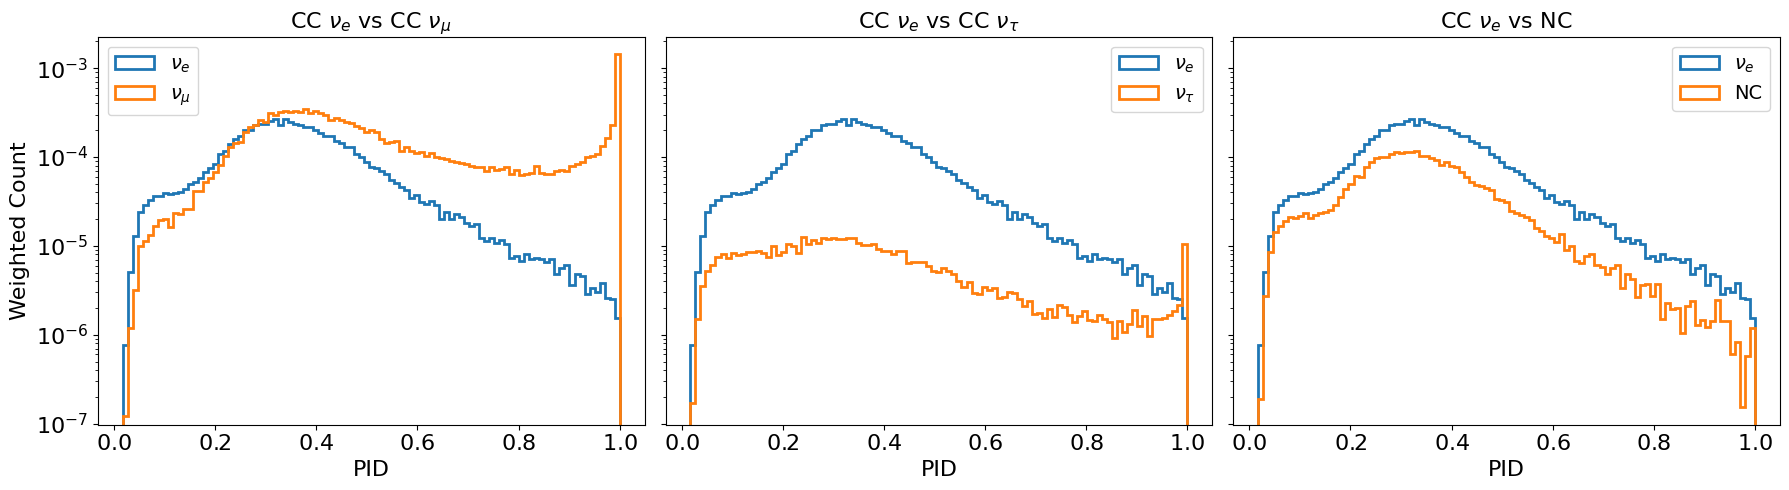

In [45]:
make_1D_hist_comparing_to_nue(pid_all, nue_boolean_all, numu_boolean_all, nutau_boolean_all, nc_boolean_all, weight_all, bins=100, xlabel='PID')

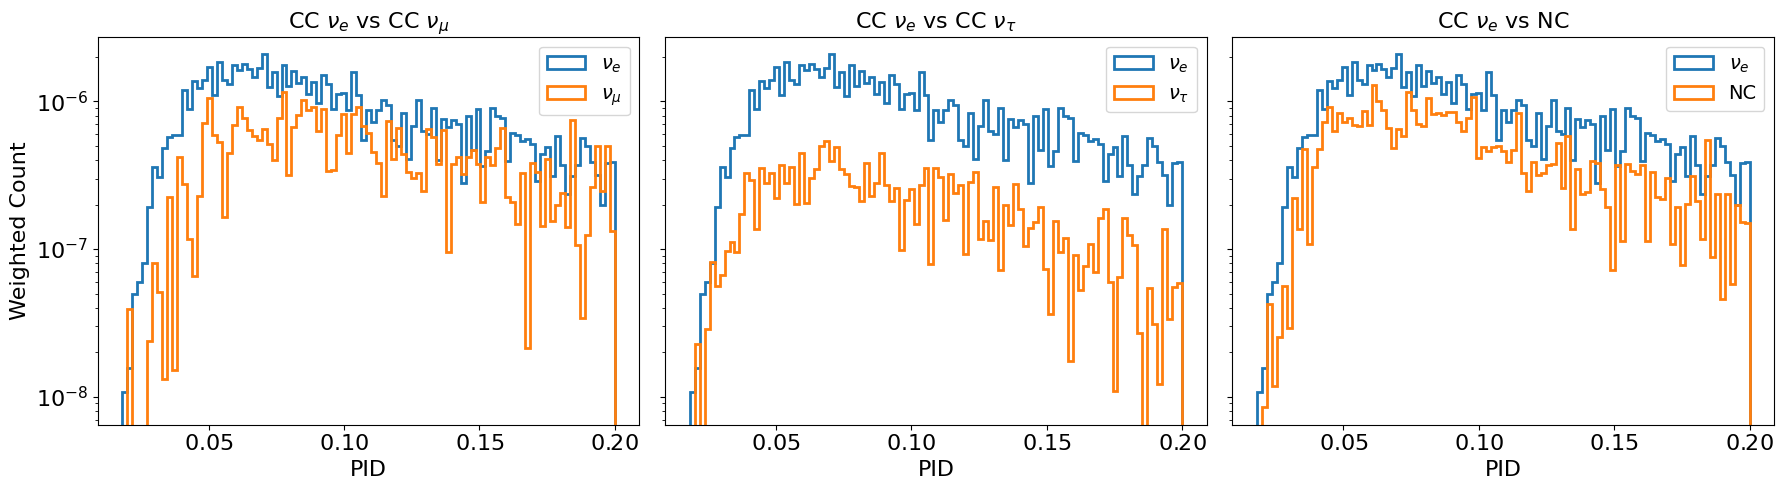

In [46]:
make_1D_hist_comparing_to_nue(pid, nue_boolean, numu_boolean, nutau_boolean, nc_boolean, weight, bins=100, xlabel='PID')

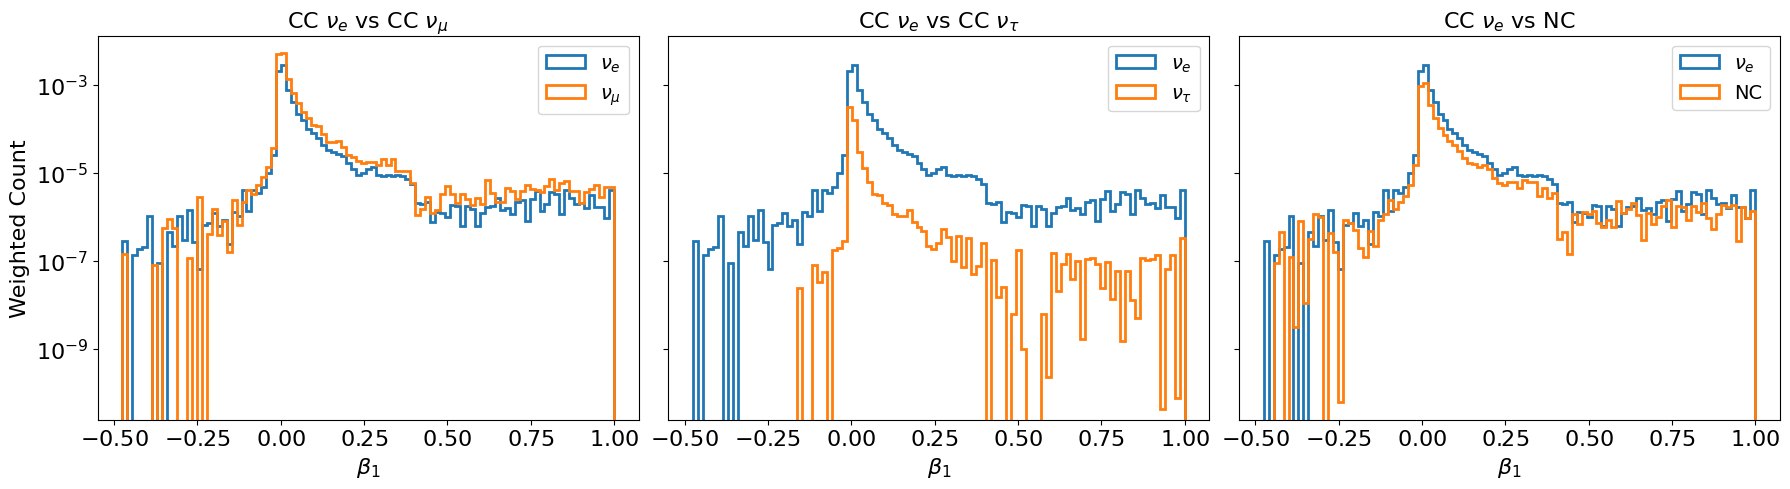

In [47]:
make_1D_hist_comparing_to_nue(beta1_arr_all, nue_boolean_all, numu_boolean_all, nutau_boolean_all, nc_boolean_all, weight_all, bins=100, xlabel=r'$\beta_{1}$')

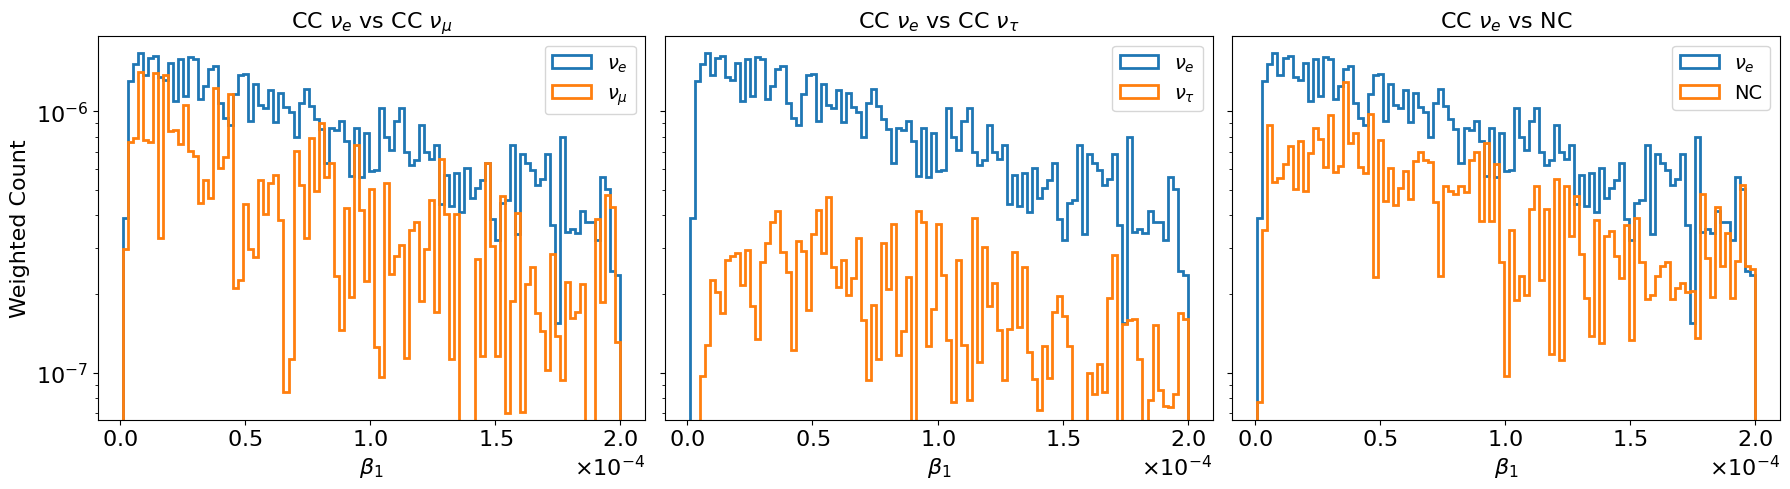

In [48]:
make_1D_hist_comparing_to_nue(beta1_arr, nue_boolean, numu_boolean, nutau_boolean, nc_boolean, weight, bins=100, xlabel=r'$\beta_{1}$')

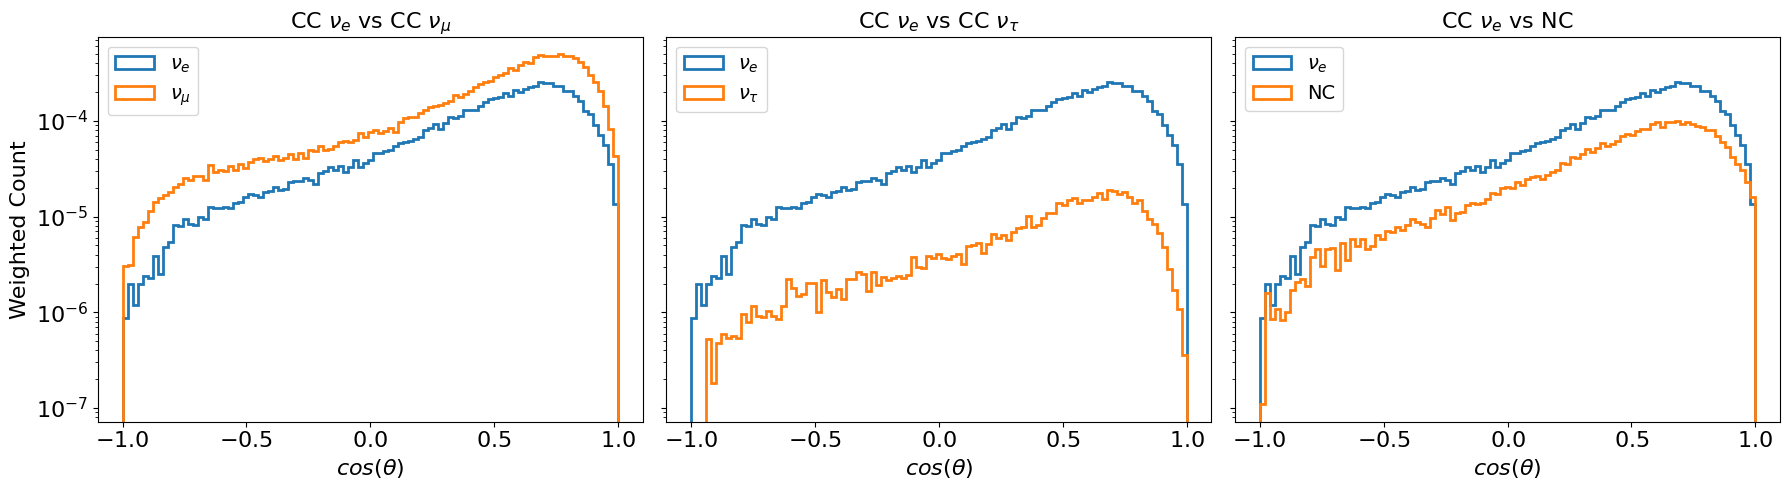

In [49]:
make_1D_hist_comparing_to_nue(ang_arr_all, nue_boolean_all, numu_boolean_all, nutau_boolean_all, nc_boolean_all, weight_all, bins=100, xlabel=r'$cos(\theta)$')

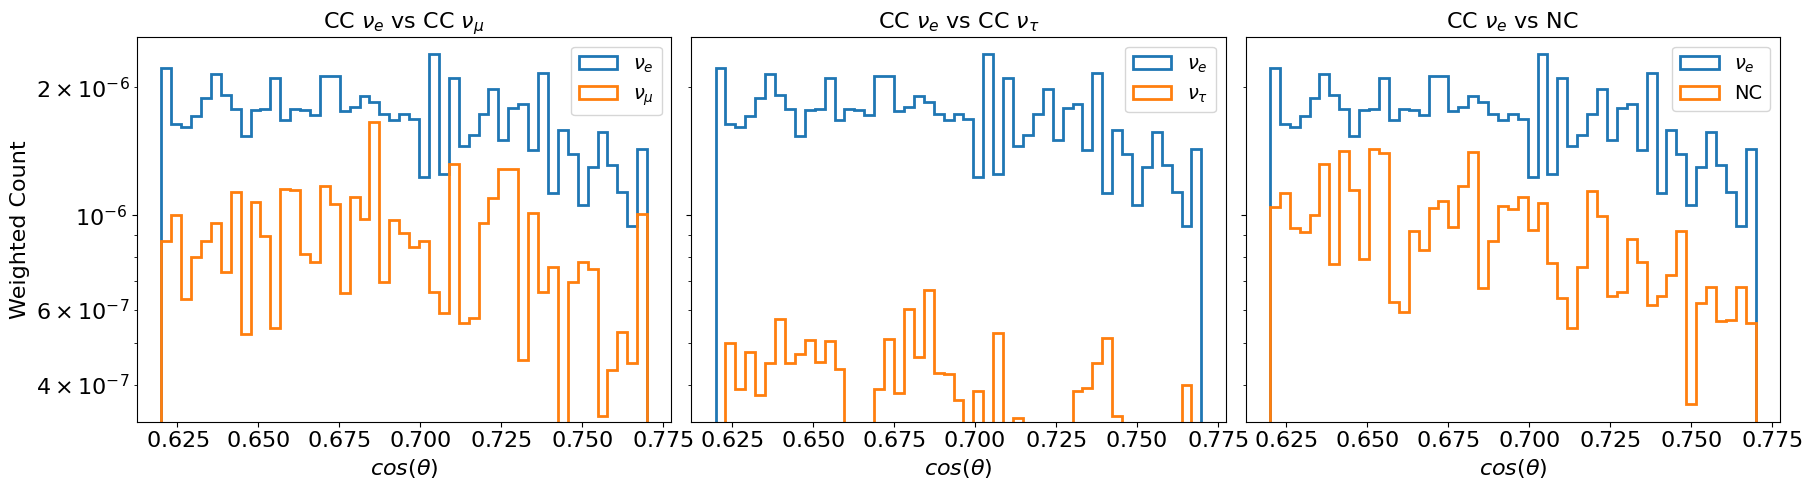

In [50]:
make_1D_hist_comparing_to_nue(ang_arr, nue_boolean, numu_boolean, nutau_boolean, nc_boolean, weight, bins=50, xlabel=r'$cos(\theta)$')

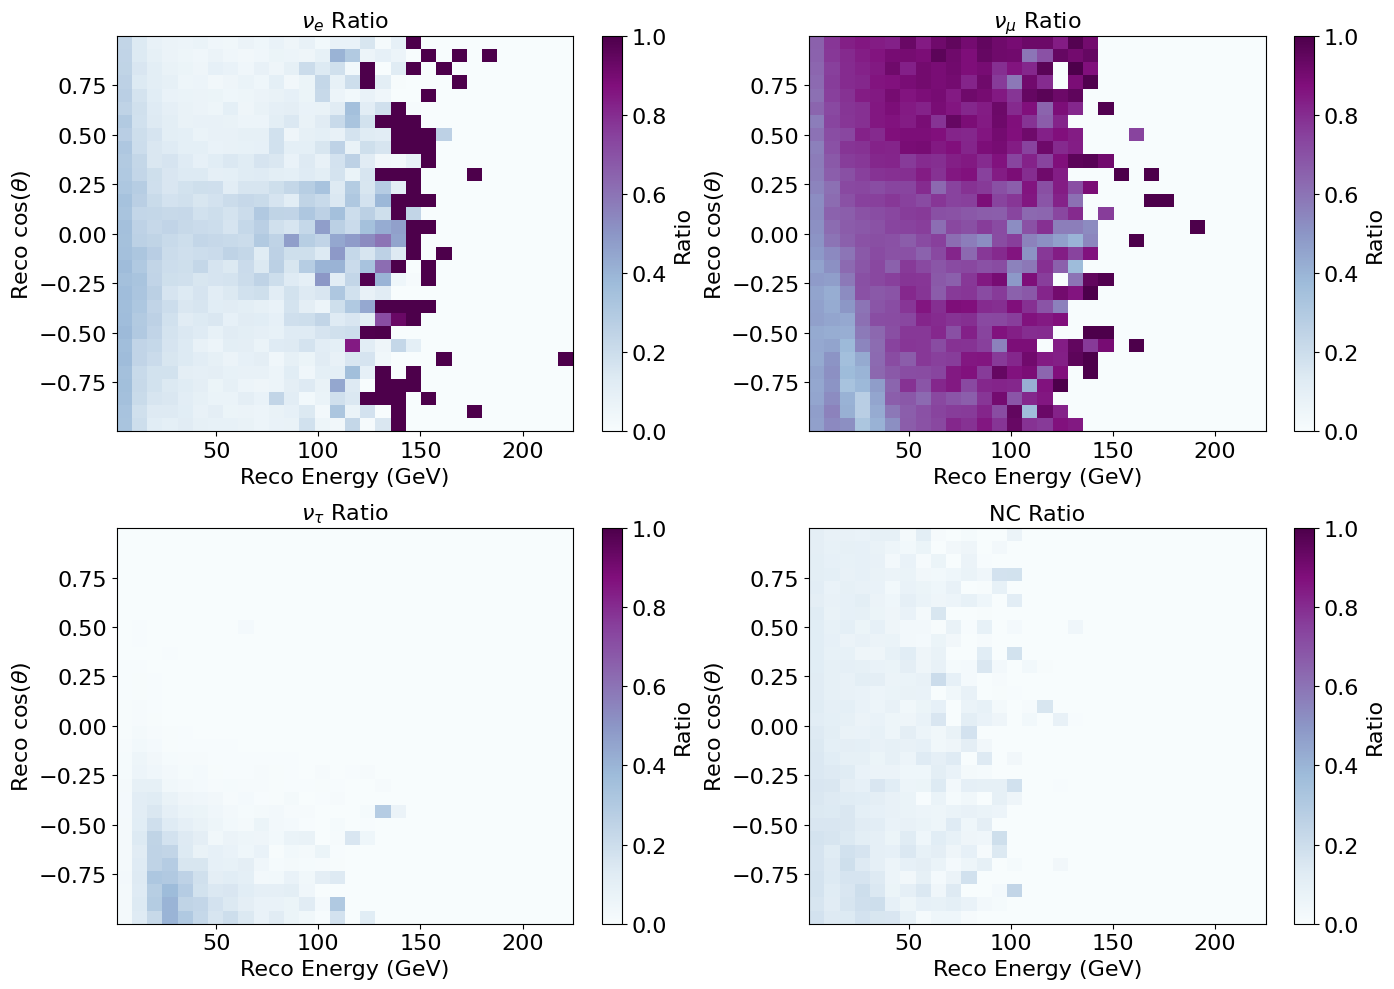

In [52]:
# Define binning
x_bins, y_bins = 30, 30
x_edges = np.linspace(np.nanmin(reco_energy_all), np.nanmax(reco_energy_all), x_bins + 1)
y_edges = np.linspace(np.nanmin(reco_zen_all), np.nanmax(reco_zen_all), y_bins + 1)

# Total histogram (used as denominator for all ratios)
hist_all, _, _ = np.histogram2d(
    reco_energy_all,
    reco_zen_all,
    bins=[x_edges, y_edges],
    weights=weight_all
)

# Define flavors and masks
flavors = [r'$\nu_{e}$', r'$\nu_{\mu}$', r'$\nu_{\tau}$', 'NC']
booleans = [nue_boolean_all, numu_boolean_all, nutau_boolean_all, nc_boolean_all]

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

# Plot each flavor
for i, (flavor, mask) in enumerate(zip(flavors, booleans)):
    hist, _, _ = np.histogram2d(
        reco_energy_all[mask],
        reco_zen_all[mask],
        bins=[x_edges, y_edges],
        weights=weight_all[mask]
    )

    ratio = np.divide(hist, hist_all, out=np.zeros_like(hist, dtype=float), where=hist_all != 0)

    im = axs[i].pcolormesh(x_edges, y_edges, ratio.T, cmap='BuPu', vmin=0, vmax=1)
    cbar = fig.colorbar(im, ax=axs[i])
    cbar.set_label('Ratio')

    axs[i].set_title(f'{flavor} Ratio')
    axs[i].set_xlabel('Reco Energy (GeV)')
    axs[i].set_ylabel(r'Reco $\cos(\theta)$')

#cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])  # [left, bottom, width, height]
#fig.colorbar(im, cax=cbar_ax, label='Ratio', ticks=[0.0, 0.25, 0.5, 0.75, 1.0])

plt.tight_layout()#(rect=[0, 0, 0.9, 1])
plt.show()

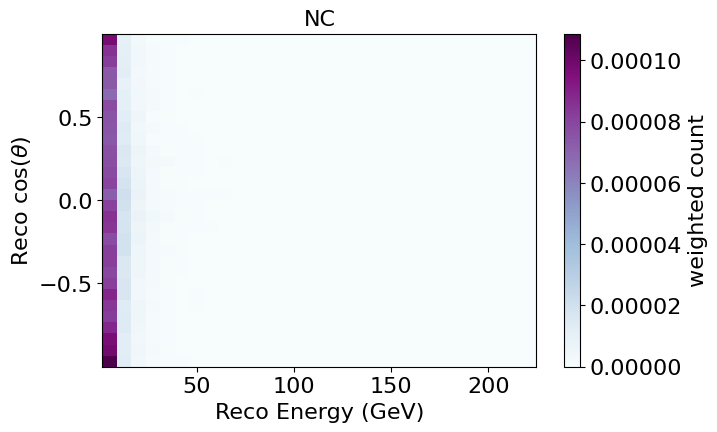

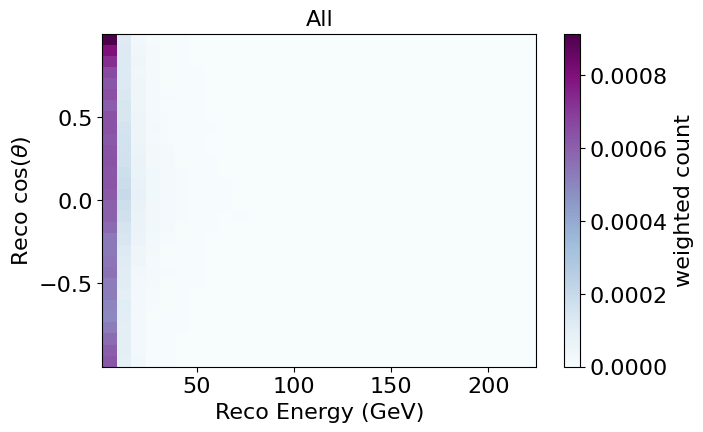

In [53]:
im = plt.pcolormesh(x_edges, y_edges, hist.T, cmap='BuPu')
plt.xlabel('Reco Energy (GeV)')
plt.ylabel(r'Reco $\cos(\theta)$')
plt.title(f'NC')
cbar = fig.colorbar(im)
cbar.set_label('weighted count')
plt.show()

im=plt.pcolormesh(x_edges, y_edges, hist_all.T, cmap='BuPu')
plt.xlabel('Reco Energy (GeV)')
plt.ylabel(r'Reco $\cos(\theta)$')
plt.title(f'All')
cbar = fig.colorbar(im)
cbar.set_label('weighted count')
plt.show()

In [ ]:
# Comparison: nue vs numu
plt.hist(arr[nue_bool], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, weights=weight[nue_bool], label=r'$EM$')
plt.hist(arr[numu_bool], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, weights=weight[numu_bool], label=r'$\nu_{\mu}$')
#axs[0].axvline(0.2, c='k', lw=2)
plt.title(r'CC $\nu_{e}$ vs CC $\nu_{\mu}$')
plt.ylabel('Weighted Count')
#axs[0].xaxis.set_major_formatter(formatter)
plt.legend()

In [38]:
np.sum(weight_all[nue_boolean_all]), np.sum(weight_all[numu_boolean_all]), np.sum(weight_all[nutau_boolean_all]), np.sum(weight_all[nc_boolean_all])

(0.007336292647770871,
 0.0143052286521816,
 0.0005459832341283187,
 0.00319102348013544)

In [39]:
np.sum(weight_all[nue_boolean_all])*60*60*24*365 + np.sum(weight_all[numu_boolean_all])*60*60*24*365 + np.sum(weight_all[nutau_boolean_all])*60*60*24*365 + np.sum(weight_all[nc_boolean_all])*60*60*24*365

800337.259456323

In [40]:
np.sum(weight[nue_boolean])*60*60*24*365 + np.sum(weight[numu_boolean])*60*60*24*365 + np.sum(weight[nutau_boolean])*60*60*24*365 + np.sum(weight[nc_boolean])

687605.6652784605

In [41]:
np.sum(weight[nue_boolean]), np.sum(weight[numu_boolean]), np.sum(weight[nutau_boolean]), np.sum(weight[nc_boolean])

(0.007127782651370633,
 0.01417878014381788,
 0.000497269719956697,
 0.003080841182949285)

Text(0, 0.5, 'log10 Rate[Hz]')

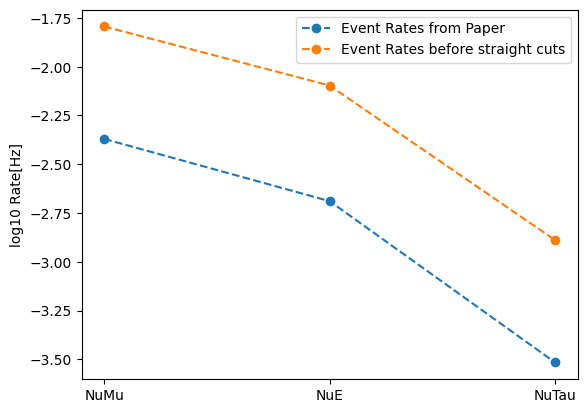

In [42]:
event_rates_from_paper = np.array([0.00426502184423342, 0.002046555949505782, 0.0003049663827126106])
event_rates_from_first_selection = np.array([np.sum(weight_all[(daughter_type_all == 13) | (daughter_type_all == -13) | (daughter_type_all == 14) | (daughter_type_all == -14)]), 
                                    np.sum(weight_all[(daughter_type_all == 11) | (daughter_type_all == -11) | (daughter_type_all == 12) | (daughter_type_all == -12)]), 
                                    np.sum(weight_all[(daughter_type_all == 15) | (daughter_type_all == -15) | (daughter_type_all == 16) | (daughter_type_all == -16)])])
event_rates_after_straight_cuts = np.array([np.sum(weight[(daughter_type == 13) | (daughter_type == -13) | (daughter_type == 14) | (daughter_type == -14)]), 
                                    np.sum(weight[(daughter_type == 11) | (daughter_type == -11) | (daughter_type == 12) | (daughter_type == -12)]), 
                                    np.sum(weight[(daughter_type == 15) | (daughter_type == -15) | (daughter_type == 16) | (daughter_type == -16)])])
event_rates_from_paper_analysis_cut = np.array([0.0019916480638308624, 0.0010369266382873482, 0.00023875515424585844])
flav_type = ['NuMu', 'NuE', 'NuTau']

plt.plot(flav_type, np.log10(event_rates_from_paper), 'o--', label='Event Rates from Paper')
#plt.plot(event_rates_from_paper_analysis_cut, '.')
plt.plot(flav_type, np.log10(event_rates_from_first_selection), 'o--', label='Event Rates before straight cuts')
plt.legend()
plt.ylabel('log10 Rate[Hz]')

Text(0, 0.5, 'log10 Rate[Hz]')

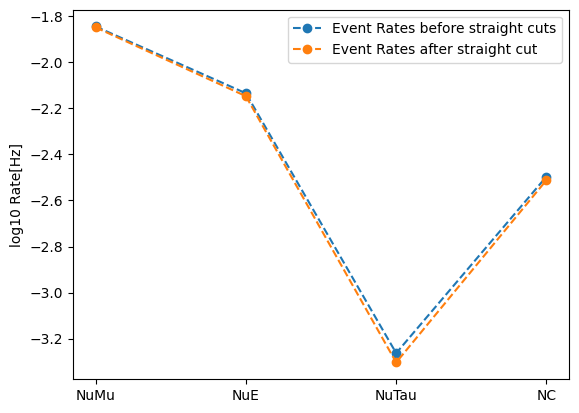

In [43]:
event_rates_from_first_selection = np.array([np.sum(weight_all[numu_boolean_all]), 
                                    np.sum(weight_all[nue_boolean_all]), 
                                    np.sum(weight_all[nutau_boolean_all]),
                                    np.sum(weight_all[nc_boolean_all])])

event_rates_after_straight_cuts = np.array([np.sum(weight[numu_boolean]), 
                                    np.sum(weight[nue_boolean]), 
                                    np.sum(weight[nutau_boolean]), 
                                    np.sum(weight[nc_boolean])
                                    ])

flav_type1 = ['NuMu', 'NuE', 'NuTau', 'NC']
plt.plot(flav_type1, np.log10(event_rates_from_first_selection), 'o--', label='Event Rates before straight cuts')
plt.plot(flav_type1, np.log10(event_rates_after_straight_cuts), 'o--', label='Event Rates after straight cut')
plt.legend()
plt.ylabel('log10 Rate[Hz]')

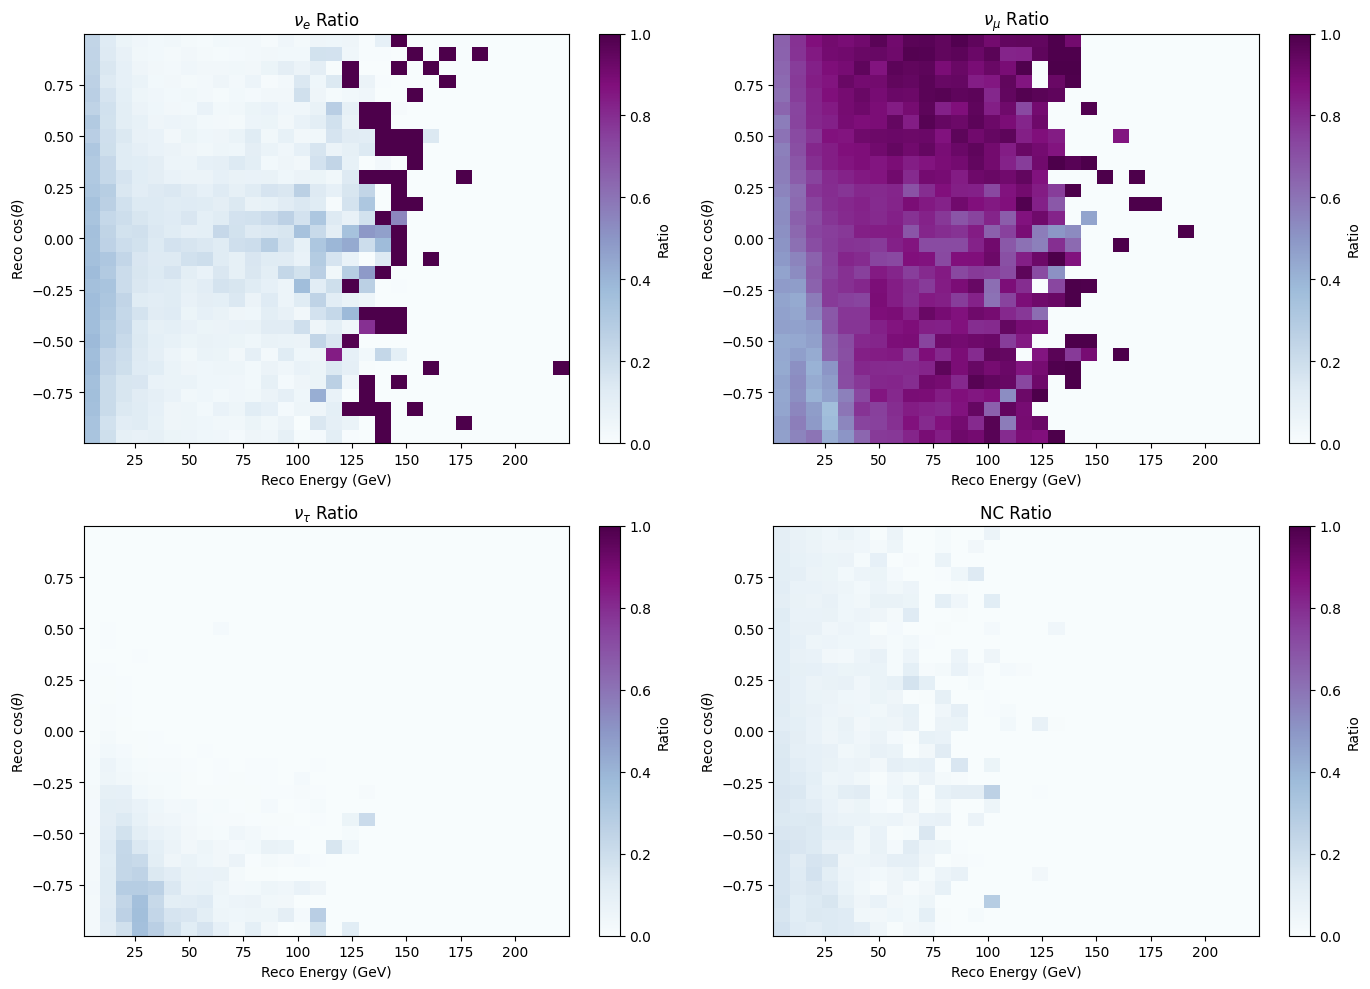

In [44]:
# Define binning
x_bins, y_bins = 30, 30
x_edges = np.linspace(np.nanmin(reco_energy), np.nanmax(reco_energy), x_bins + 1)
y_edges = np.linspace(np.nanmin(reco_zen), np.nanmax(reco_zen), y_bins + 1)

# Total histogram (used as denominator for all ratios)
hist_all, _, _ = np.histogram2d(
    reco_energy,
    reco_zen,
    bins=[x_edges, y_edges],
    weights=weight
)

# Define flavors and masks
flavors = [r'$\nu_{e}$', r'$\nu_{\mu}$', r'$\nu_{\tau}$', 'NC']
booleans = [nue_boolean, numu_boolean, nutau_boolean, nc_boolean]

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

# Plot each flavor
for i, (flavor, mask) in enumerate(zip(flavors, booleans)):
    hist, _, _ = np.histogram2d(
        reco_energy[mask],
        reco_zen[mask],
        bins=[x_edges, y_edges],
        weights=weight[mask]
    )

    ratio = np.divide(hist, hist_all, out=np.zeros_like(hist, dtype=float), where=hist != 0)

    im = axs[i].pcolormesh(x_edges, y_edges, ratio.T, cmap='BuPu', vmin=0, vmax=1)
    cbar = fig.colorbar(im, ax=axs[i])
    cbar.set_label('Ratio')

    axs[i].set_title(f'{flavor} Ratio')
    axs[i].set_xlabel('Reco Energy (GeV)')
    axs[i].set_ylabel(r'Reco $\cos(\theta)$')

plt.tight_layout()
plt.show()

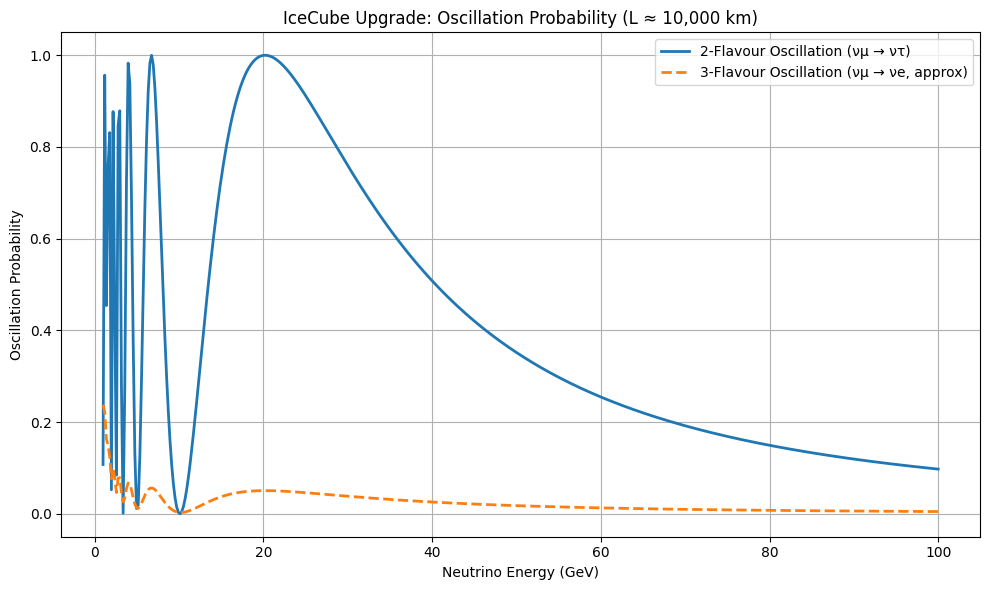

In [21]:
# Updated parameters for IceCube Upgrade scenario (e.g., improved low-energy sensitivity)
# We'll model a baseline of up to 10,000 km (Earth diameter ~12,742 km)
# Energy range extended for DeepCore/Upgrade (1 to 50 GeV)

# Conversion constant: 1.27 appears in oscillation formula when using proper units
const = 1.27

# Two-flavour parameters (e.g., mu-tau)
theta_2f = np.radians(45)  # maximal mixing
dm2_2f = 2.5e-3  # eV^2

# Three-flavour parameters (approximated)
theta12 = np.radians(33.44)
theta13 = np.radians(8.57)
theta23 = np.radians(49.2)
dm2_21 = 7.42e-5  # eV^2
dm2_31 = 2.514e-3  # eV^2

# Approximate 3-flavour probability for nu_mu -> nu_e (vacuum, no CP phase)
# This is a simplified version of the full formula
sin2_2theta13 = np.sin(2 * theta13)**2
sin2_theta23 = np.sin(theta23)**2
sin2_theta12 = np.sin(2 * theta12)**2
cos_theta13 = np.cos(theta13)

L_upgrade = 10000  # km, approximate Earth diameter
E_upgrade = np.linspace(1, 100, 500)  # Neutrino energy in GeV

# Recalculate oscillation probabilities for upgraded scenario

# Two-flavour oscillation probability
P_2f_upgrade = np.sin(2 * theta_2f)**2 * np.sin(const * dm2_2f * L_upgrade / E_upgrade)**2

# Three-flavour approximate oscillation probability
P_3f_upgrade = (
    sin2_2theta13 * sin2_theta23 * np.sin(const * dm2_31 * L_upgrade / E_upgrade)**2 +
    cos_theta13**4 * sin2_theta12 * np.cos(theta23)**2 * np.sin(const * dm2_21 * L_upgrade / E_upgrade)**2
)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(E_upgrade, P_2f_upgrade, label='2-Flavour Oscillation (νμ → ντ)', linewidth=2)
plt.plot(E_upgrade, P_3f_upgrade, label='3-Flavour Oscillation (νμ → νe, approx)', linewidth=2, linestyle='--')
plt.xlabel('Neutrino Energy (GeV)')
plt.ylabel('Oscillation Probability')
plt.title('IceCube Upgrade: Oscillation Probability (L ≈ 10,000 km)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

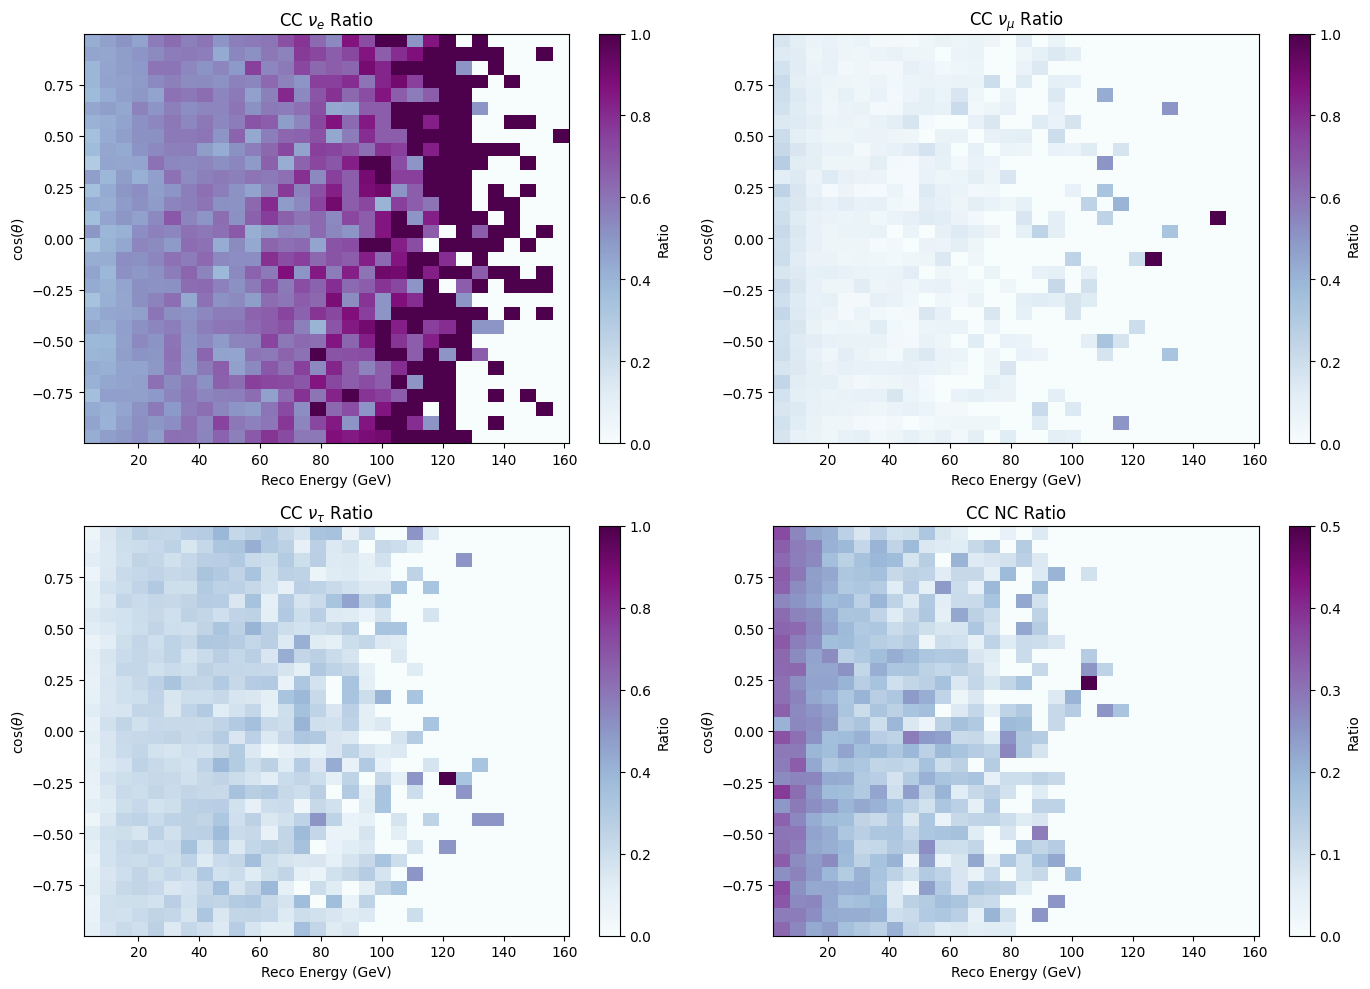

In [182]:
# Define binning
x_bins, y_bins = 30, 30
x_edges = np.linspace(np.nanmin(reco_energy), np.nanmax(reco_energy), x_bins + 1)
y_edges = np.linspace(np.nanmin(reco_zen), np.nanmax(reco_zen), y_bins + 1)

# Total histogram (used as denominator for all ratios)
hist_all, _, _ = np.histogram2d(
    reco_energy,
    reco_zen,
    bins=[x_edges, y_edges]
)

# Define flavors and masks
flavors = [r'$\nu_{e}$', r'$\nu_{\mu}$', r'$\nu_{\tau}$', 'NC']
booleans = [nue_boolean, numu_boolean, nutau_boolean, nc_boolean]

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

# Plot each flavor
for i, (flavor, mask) in enumerate(zip(flavors, booleans)):
    hist, _, _ = np.histogram2d(
        reco_energy[mask],
        reco_zen[mask],
        bins=[x_edges, y_edges]
    )

    ratio = np.divide(hist, hist_all, out=np.zeros_like(hist, dtype=float), where=hist != 0)

    im = axs[i].pcolormesh(x_edges, y_edges, ratio.T, cmap='BuPu')
    cbar = fig.colorbar(im, ax=axs[i])
    cbar.set_label('Ratio')

    axs[i].set_title(f'CC {flavor} Ratio')
    axs[i].set_xlabel('Reco Energy (GeV)')
    axs[i].set_ylabel(r'$\cos(\theta)$')

plt.tight_layout()
plt.show()

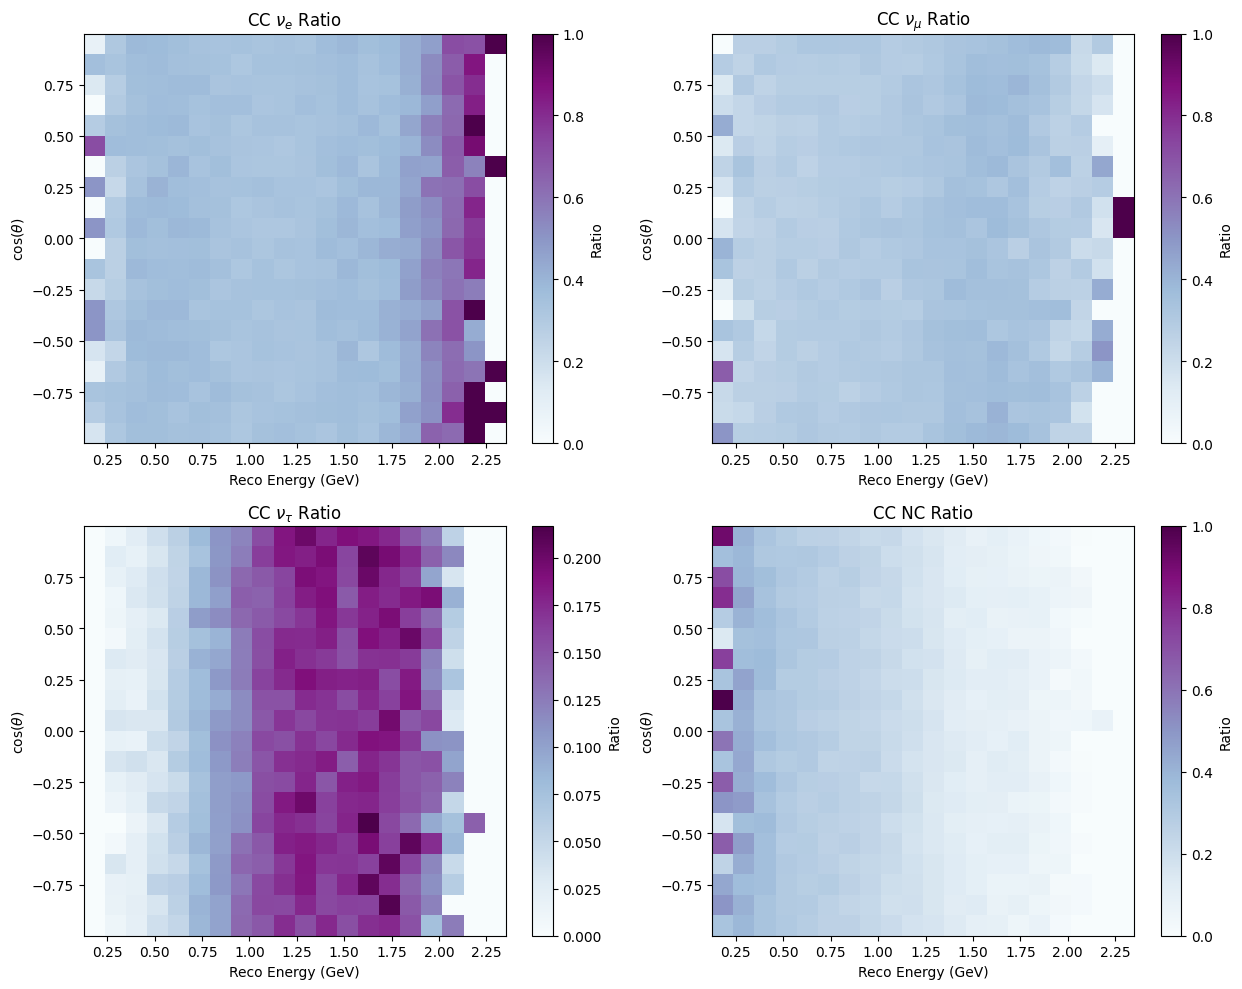

In [183]:
# Define binning
x_bins, y_bins = 20, 20
x_edges = np.linspace(np.nanmin(np.log10(reco_energy_all)), np.nanmax(np.log10(reco_energy_all)), x_bins + 1)
y_edges = np.linspace(np.nanmin(reco_zen_all), np.nanmax(reco_zen_all), y_bins + 1)

# Total histogram (used as denominator for all ratios)
hist_all, _, _ = np.histogram2d(
    np.log10(reco_energy_all),
    reco_zen_all,
    bins=[x_edges, y_edges]
)

# Define flavors and masks
flavors = [r'$\nu_{e}$', r'$\nu_{\mu}$', r'$\nu_{\tau}$', 'NC']
booleans = [nue_boolean_all, numu_boolean_all, nutau_boolean_all, nc_boolean_all]

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

# Plot each flavor
for i, (flavor, mask) in enumerate(zip(flavors, booleans)):
    hist, _, _ = np.histogram2d(
        np.log10(reco_energy_all[mask]),
        reco_zen_all[mask],
        bins=[x_edges, y_edges]
    )

    ratio = np.divide(hist, hist_all, out=np.zeros_like(hist, dtype=float), where=hist_all != 0)

    im = axs[i].pcolormesh(x_edges, y_edges, ratio.T, cmap='BuPu')
    cbar = fig.colorbar(im, ax=axs[i])
    cbar.set_label('Ratio')

    axs[i].set_title(f'CC {flavor} Ratio')
    axs[i].set_xlabel('Reco Energy (GeV)')
    axs[i].set_ylabel(r'$\cos(\theta)$')

plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for colorbar on the right
plt.show()

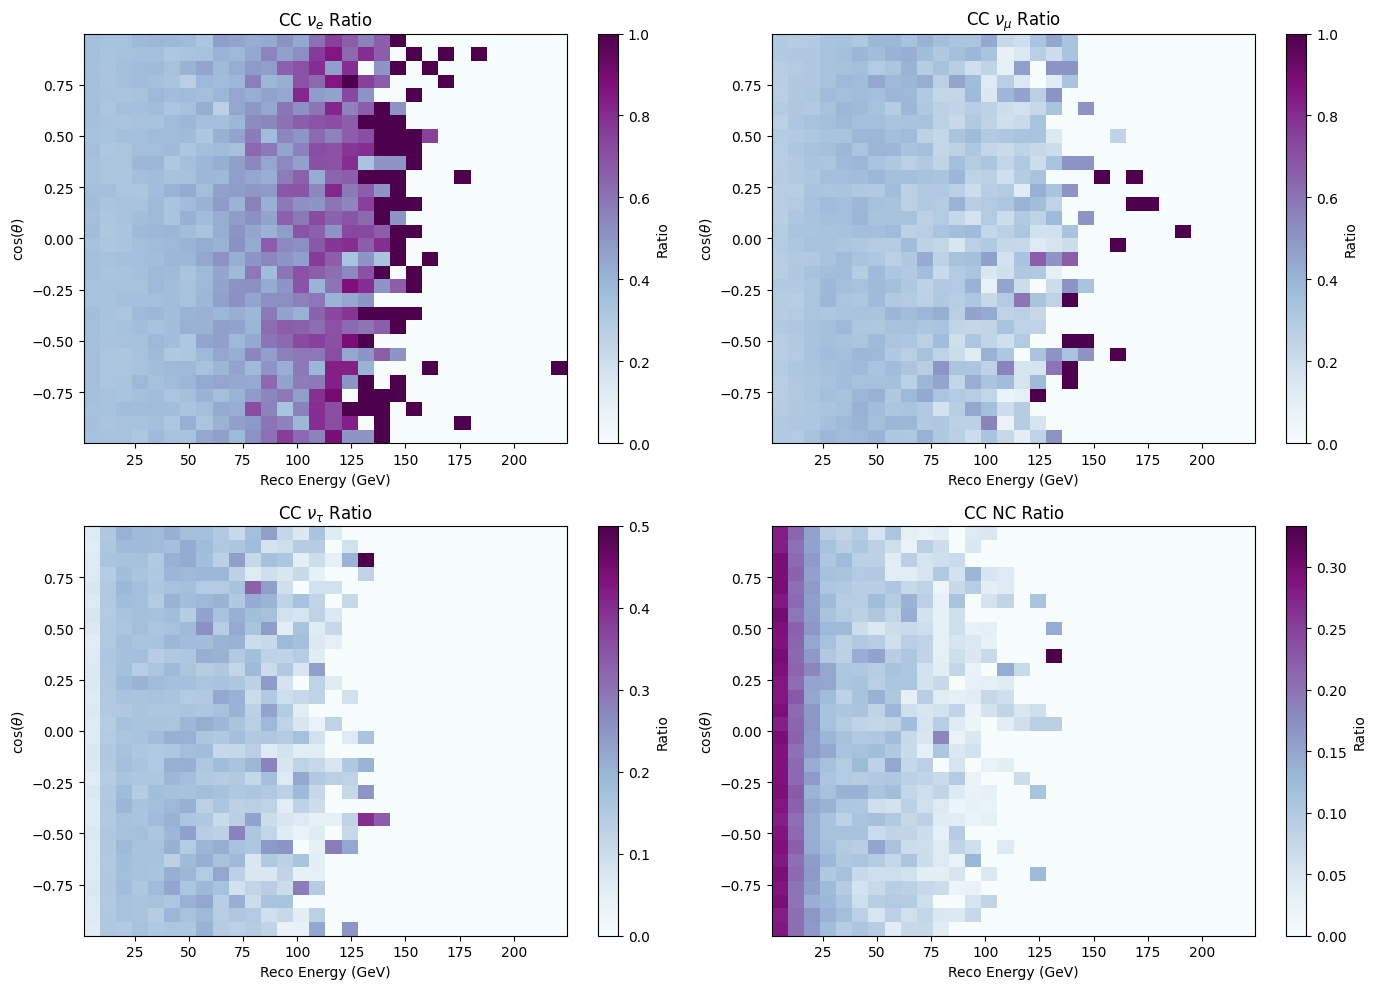

In [184]:
# Define binning (LINEAR energy scale now)
x_bins, y_bins = 30, 30
x_edges = np.linspace(np.nanmin(reco_energy_all), np.nanmax(reco_energy_all), x_bins + 1)
y_edges = np.linspace(np.nanmin(reco_zen_all), np.nanmax(reco_zen_all), y_bins + 1)

# Total histogram (used as denominator for all ratios)
hist_all, _, _ = np.histogram2d(
    reco_energy_all,
    reco_zen_all,
    bins=[x_edges, y_edges]
)

# Define flavors and masks
flavors = [r'$\nu_{e}$', r'$\nu_{\mu}$', r'$\nu_{\tau}$', 'NC']
booleans = [nue_boolean_all, numu_boolean_all, nutau_boolean_all, nc_boolean_all]

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

# Plot each flavor
for i, (flavor, mask) in enumerate(zip(flavors, booleans)):
    hist, _, _ = np.histogram2d(
        reco_energy_all[mask],
        reco_zen_all[mask],
        bins=[x_edges, y_edges]
    )

    ratio = np.divide(hist, hist_all, out=np.zeros_like(hist, dtype=float), where=hist_all != 0)

    im = axs[i].pcolormesh(x_edges, y_edges, ratio.T, cmap='BuPu')
    cbar = fig.colorbar(im, ax=axs[i])
    cbar.set_label('Ratio')

    axs[i].set_title(f'CC {flavor} Ratio')
    axs[i].set_xlabel('Reco Energy (GeV)')
    axs[i].set_ylabel(r'$\cos(\theta)$')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3610/53032226.py:11: RuntimeWarning: invalid value encountered in divide
  plt.pcolormesh(x_edges, y_edges, (hist/hist_all).T, cmap=plt.cm.BuPu)


Text(0.5, 1.0, 'CC $\\nu_{e}$ Ratio')

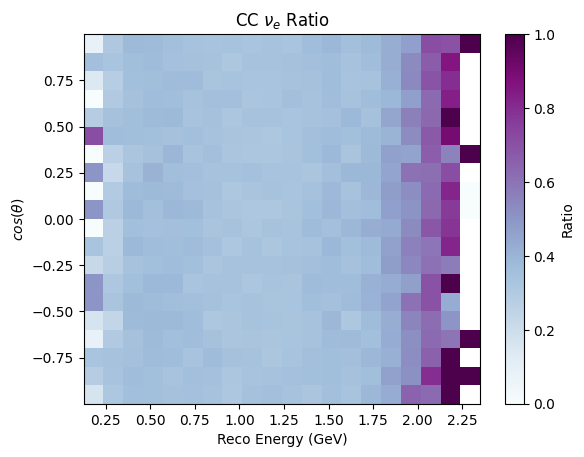

In [191]:
#ratio of nue events in each bin

x_bins, y_bins = 20, 20
x_edges = np.linspace(min(np.log10(reco_energy_all)), max(np.log10(reco_energy_all)), x_bins + 1)
y_edges = np.linspace(min(reco_zen_all), max(reco_zen_all), y_bins + 1)

hist_all, _, _ = np.histogram2d(np.log10(reco_energy_all), reco_zen_all, bins=[x_edges, y_edges])#, weights=weight_no_osc_all)
hist, _, _ = np.histogram2d(np.log10(reco_energy_all[nue_boolean_all]), reco_zen_all[nue_boolean_all], bins=[x_edges, y_edges])#, weights=weight_no_osc_all[nue_boolean_all])

#plt.subplot(1, 2, 1)
plt.pcolormesh(x_edges, y_edges, (hist/hist_all).T, cmap=plt.cm.BuPu)
plt.colorbar(label='Ratio')
plt.xlabel('Reco Energy (GeV)')
plt.ylabel(r'$cos(\theta)$')
plt.title(r'CC $\nu_{e}$ Ratio')

/tmp/ipykernel_1288/4122374789.py:9: RuntimeWarning: invalid value encountered in divide
  plt.pcolormesh(x_edges, y_edges, (hist/hist_all).T, cmap=plt.cm.BuPu)


Text(0.5, 1.0, 'CC $\\nu_{\\mu}$ Ratio')

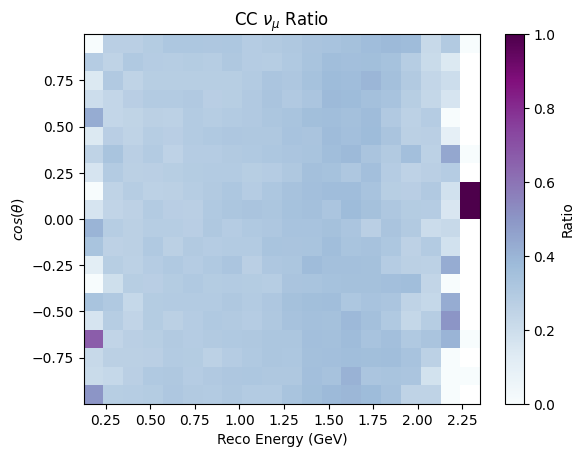

In [51]:
x_bins, y_bins = 20, 20
x_edges = np.linspace(min(np.log10(reco_energy_all)), max(np.log10(reco_energy_all)), x_bins + 1)
y_edges = np.linspace(min(reco_zen_all), max(reco_zen_all), y_bins + 1)

hist_all, _, _ = np.histogram2d(np.log10(reco_energy_all), reco_zen_all, bins=[x_edges, y_edges])#, weights=weight_no_osc_all)
hist, _, _ = np.histogram2d(np.log10(reco_energy_all[numu_boolean_all]), reco_zen_all[numu_boolean_all], bins=[x_edges, y_edges])#, weights=weight_no_osc_all[nue_boolean_all])

#plt.subplot(1, 2, 1)
plt.pcolormesh(x_edges, y_edges, (hist/hist_all).T, cmap=plt.cm.BuPu)
plt.colorbar(label='Ratio')
plt.xlabel('Reco Energy (GeV)')
plt.ylabel(r'$cos(\theta)$')
plt.title(r'CC $\nu_{\mu}$ Ratio')

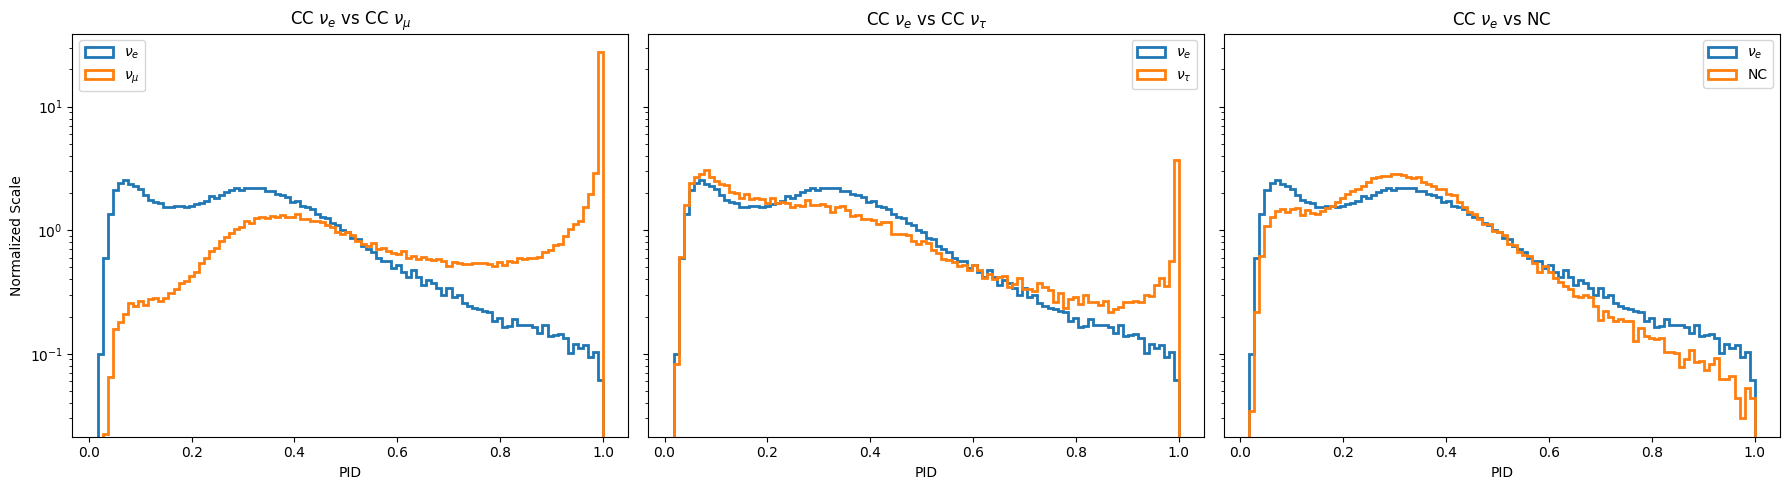

In [36]:
bin_edges = np.linspace(np.nanmin(pid_all), np.nanmax(pid_all), 101)  # 100 equal-width bins

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Comparison: nue vs numu
axs[0].hist(pid_all[nue_boolean_all], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{e}$')
axs[0].hist(pid_all[numu_boolean_all], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{\mu}$')
axs[0].set_title(r'CC $\nu_{e}$ vs CC $\nu_{\mu}$')
axs[0].set_ylabel('Normalized Scale')
axs[0].legend()

# Comparison: nue vs nutau
axs[1].hist(pid_all[nue_boolean_all], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{e}$')
axs[1].hist(pid_all[nutau_boolean_all], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{\tau}$')
axs[1].set_title(r'CC $\nu_{e}$ vs CC $\nu_{\tau}$')
axs[1].legend()

# Comparison: nue vs nc
axs[2].hist(pid_all[nue_boolean_all], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{e}$')
axs[2].hist(pid_all[nc_boolean_all], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label='NC')
axs[2].set_title(r'CC $\nu_{e}$ vs NC')
axs[2].legend()

# Common labels
for ax in axs:
    ax.set_xlabel(r'PID')
    #ax.set_ylabel('Normalized Scale')

plt.tight_layout()
plt.show()

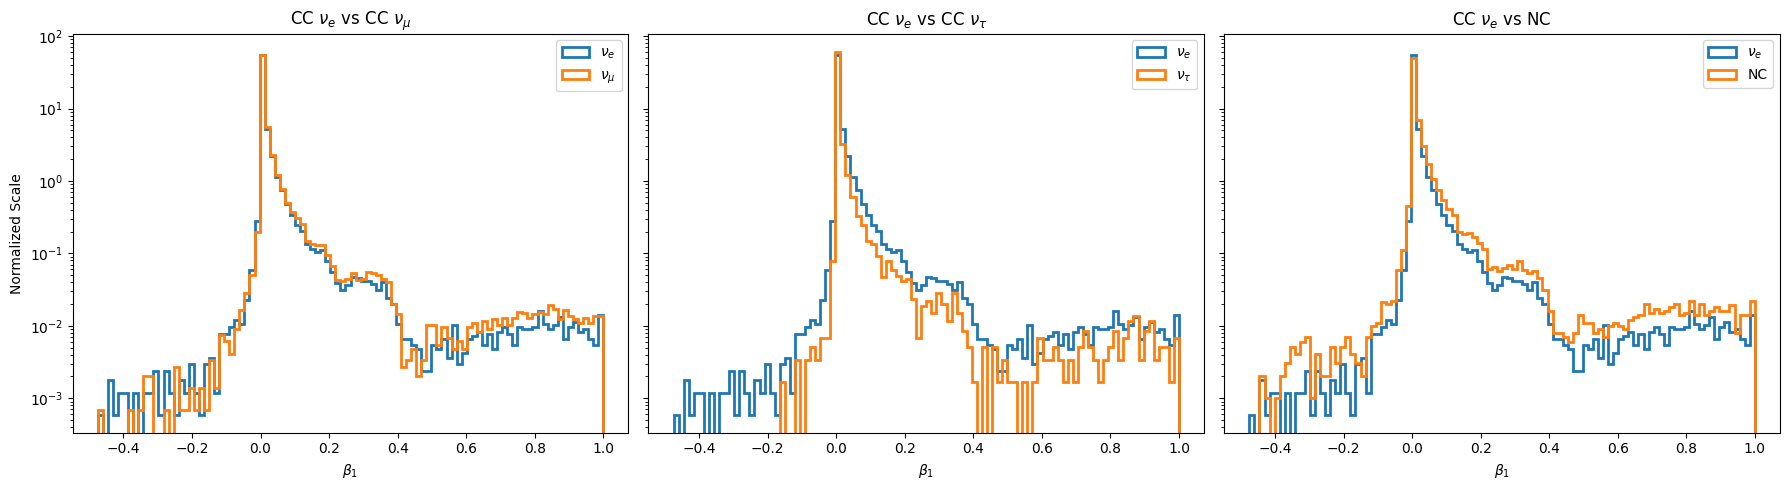

In [34]:
bin_edges = np.linspace(np.nanmin(beta1_arr_all), np.nanmax(beta1_arr_all), 101)  # 100 equal-width bins

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Comparison: nue vs numu
axs[0].hist(beta1_arr_all[nue_boolean_all], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{e}$')
axs[0].hist(beta1_arr_all[numu_boolean_all], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{\mu}$')
axs[0].set_title(r'CC $\nu_{e}$ vs CC $\nu_{\mu}$')
axs[0].set_ylabel('Normalized Scale')
axs[0].legend()

# Comparison: nue vs nutau
axs[1].hist(beta1_arr_all[nue_boolean_all], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{e}$')
axs[1].hist(beta1_arr_all[nutau_boolean_all], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{\tau}$')
axs[1].set_title(r'CC $\nu_{e}$ vs CC $\nu_{\tau}$')
axs[1].legend()

# Comparison: nue vs nc
axs[2].hist(beta1_arr_all[nue_boolean_all], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{e}$')
axs[2].hist(beta1_arr_all[nc_boolean_all], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label='NC')
axs[2].set_title(r'CC $\nu_{e}$ vs NC')
axs[2].legend()

# Common labels
for ax in axs:
    ax.set_xlabel(r'$\beta_{1}$')
    #ax.set_ylabel('Normalized Scale')

plt.tight_layout()
plt.show()

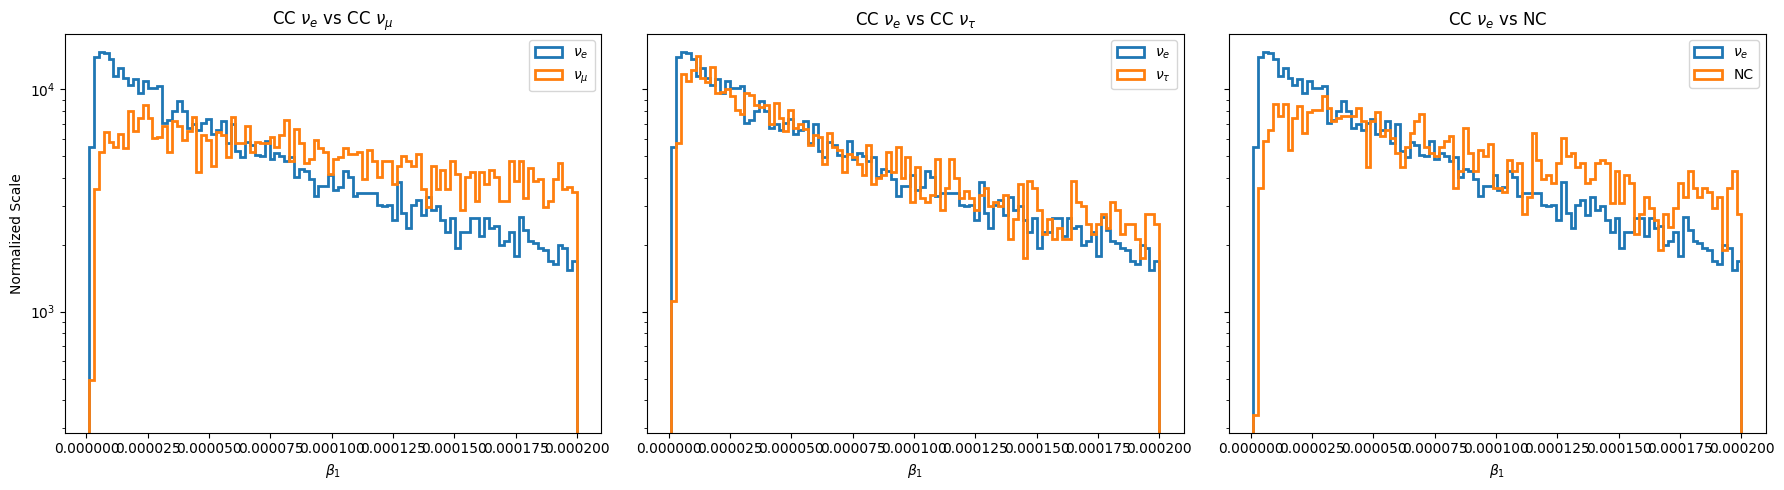

In [35]:
bin_edges = np.linspace(np.nanmin(beta1_arr), np.nanmax(beta1_arr), 101)  # 100 equal-width bins

fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Comparison: nue vs numu
axs[0].hist(beta1_arr[nue_boolean], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{e}$')
axs[0].hist(beta1_arr[numu_boolean], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{\mu}$')
axs[0].set_title(r'CC $\nu_{e}$ vs CC $\nu_{\mu}$')
axs[0].set_ylabel('Normalized Scale')
axs[0].legend()

# Comparison: nue vs nutau
axs[1].hist(beta1_arr[nue_boolean], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{e}$')
axs[1].hist(beta1_arr[nutau_boolean], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{\tau}$')
axs[1].set_title(r'CC $\nu_{e}$ vs CC $\nu_{\tau}$')
axs[1].legend()

# Comparison: nue vs nc
axs[2].hist(beta1_arr[nue_boolean], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label=r'$\nu_{e}$')
axs[2].hist(beta1_arr[nc_boolean], bins=bin_edges, histtype='step', lw = 2, density=True, log=True, label='NC')
axs[2].set_title(r'CC $\nu_{e}$ vs NC')
axs[2].legend()

# Common labels
for ax in axs:
    ax.set_xlabel(r'$\beta_{1}$')
    #ax.set_ylabel('Normalized Scale')

plt.tight_layout()
plt.show()

In [ ]:
#ratio of nue events in each bin

x_bins, y_bins = 20, 20
x_edges = np.linspace(min(np.log10(reco_energy_all)), max(np.log10(reco_energy_all)), x_bins + 1)
y_edges = np.linspace(min(reco_zen_all), max(reco_zen_all), y_bins + 1)

hist_all, _, _ = np.histogram2d(np.log10(reco_energy_all), reco_zen_all, bins=[x_edges, y_edges], weights=weight_no_osc_all)
hist, _, _ = np.histogram2d(np.log10(reco_energy_all[nue_boolean_all]), reco_zen_all[nue_boolean_all], bins=[x_edges, y_edges], weights=weight_no_osc_all[nue_boolean_all])

#plt.subplot(1, 2, 1)
plt.pcolormesh(x_edges, y_edges, (hist/hist_all).T, cmap=plt.cm.BuPu)
plt.colorbar(label='Ratio')
plt.xlabel('Reco Energy (GeV)')
plt.ylabel(r'$cos(\theta)$')
plt.title(r'\text{CC} \nu_{e} \text{Ratio}')

In [4]:
filelist = sorted(glob('/data/user/akatil/electron_neutrino/for_real/dataset_complete/enriched_all_with_beta/upgrade_genie_level4_queso_12*028_000*.i3.zst'))

np.random.seed(43)
#filelist = np.random.choice(filelist, size=200, replace=False)

In [5]:
beta1_arr = []
median_arr = []
reco_energy = []
reco_zen = []
weight = []
weight_no_osc = []
pid = []

count = 0
for file in filelist:
    count += 1
    if count % 50 == 0:
        print(count)
    infile=dataio.I3File(file)
    while(infile.more()):
        frame = infile.pop_frame()
        if frame.Stop == icetray.I3Frame.Physics:
            
            mctree = frame["I3MCTree"]
            primary = mctree.primaries

            daughter = dataclasses.I3MCTree.first_child(mctree, primary[0].id)

            if daughter.type == 11 or daughter.type == -11:

                beta1_arr.append(frame['Beta1'].value)
                median_arr.append(frame['median_angle'].value)
    
                reco_energy.append(frame["graphnet_dynedge_energy_reconstruction_energy_pred"].value)
                x = frame['graphnet_dynedge_direction_reconstruction_dir_x_pred'].value
                y = frame['graphnet_dynedge_direction_reconstruction_dir_y_pred'].value
                z = frame['graphnet_dynedge_direction_reconstruction_dir_z_pred'].value
                rho = np.sqrt(x**2+y**2)
    
                reco_zeniths = np.arctan2(rho,z)
    
                reco_zen.append(np.cos(reco_zeniths))

                pid.append(frame['graphnet_dynedge_track_classification_track_pred'].value)

                if daughter.type == 11:
                    weight.append(frame["I3MCWeightDict"]["weight"]/1000)
                    weight_no_osc.append(frame["I3MCWeightDict"]["weight_no_osc"]/1000)
                else:
                    weight.append(frame["I3MCWeightDict"]["weight"]/500)
                    weight_no_osc.append(frame["I3MCWeightDict"]["weight_no_osc"]/500)             

50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500


In [25]:
beta1_arr = np.array(beta1_arr)
ang_arr = np.array(median_arr)
reco_energy = np.array(reco_energy)
reco_zen = np.array(reco_zen)
weight = np.array(weight)
weight_no_osc = np.array(weight_no_osc)
pid = np.array(pid)

enrich_boolean = (beta1_arr >= 0) & (beta1_arr <= 0.0002) & (ang_arr >= 0.62) & (ang_arr <= 0.77) & (pid <= 0.4) #(reco_zen <= 0) & (pid <= 0.4)

/tmp/ipykernel_467/3196414554.py:9: RuntimeWarning: invalid value encountered in divide
  plt.pcolormesh(x_edges, y_edges, (hist/hist_all).T, cmap=plt.cm.BuPu)


Text(0.5, 1.0, 'Ratio')

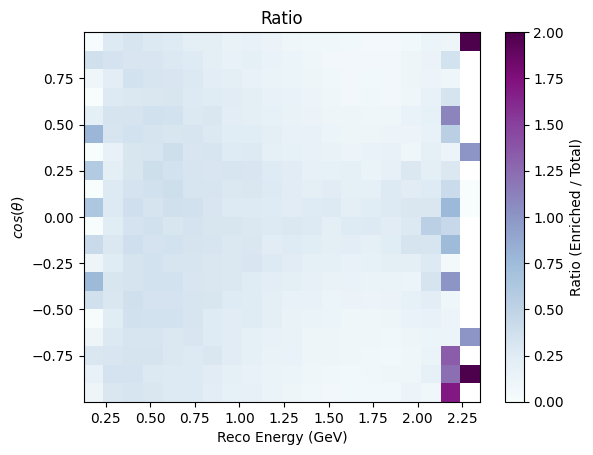

In [64]:
x_bins, y_bins = 20, 20
x_edges = np.linspace(min(np.log10(reco_energy_all)), max(np.log10(reco_energy_all)), x_bins + 1)
y_edges = np.linspace(min(reco_zen_all), max(reco_zen_all), y_bins + 1)

hist_all, _, _ = np.histogram2d(np.log10(reco_energy_all), reco_zen_all, bins=[x_edges, y_edges], weights=weight_no_osc_all)
hist, _, _ = np.histogram2d(np.log10(reco_energy), reco_zen, bins=[x_edges, y_edges], weights=weight_no_osc)

#plt.subplot(1, 2, 1)
plt.pcolormesh(x_edges, y_edges, (hist/hist_all).T, cmap=plt.cm.BuPu)
plt.colorbar(label='Ratio (Enriched / Total)')
plt.xlabel('Reco Energy (GeV)')
plt.ylabel(r'$cos(\theta)$')
plt.title('Ratio')

/tmp/ipykernel_467/3790682153.py:9: RuntimeWarning: invalid value encountered in divide
  plt.pcolormesh(x_edges, y_edges, (hist/hist_all).T, cmap=plt.cm.viridis)


Text(0.5, 1.0, 'Ratio')

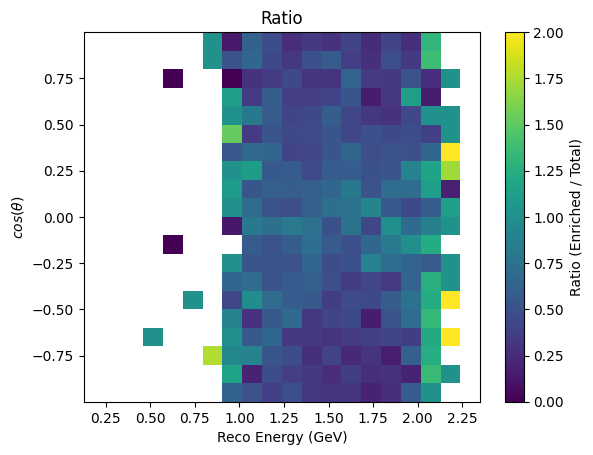

In [65]:
x_bins, y_bins = 20, 20
x_edges = np.linspace(min(np.log10(reco_energy_all)), max(np.log10(reco_energy_all)), x_bins + 1)
y_edges = np.linspace(min(reco_zen_all), max(reco_zen_all), y_bins + 1)

hist_all, _, _ = np.histogram2d(np.log10(reco_energy_all[enrich_boolean_all]), reco_zen_all[enrich_boolean_all], bins=[x_edges, y_edges], weights=weight_no_osc_all[enrich_boolean_all])
hist, _, _ = np.histogram2d(np.log10(reco_energy[enrich_boolean]), reco_zen[enrich_boolean], bins=[x_edges, y_edges], weights=weight_no_osc[enrich_boolean])

#plt.subplot(1, 2, 1)
plt.pcolormesh(x_edges, y_edges, (hist/hist_all).T, cmap=plt.cm.viridis)
plt.colorbar(label='Ratio (Enriched / Total)')
plt.xlabel('Reco Energy (GeV)')
plt.ylabel(r'$cos(\theta)$')
plt.title('Ratio')

In [62]:
(hist/hist_all).T

/tmp/ipykernel_467/3230551804.py:1: RuntimeWarning: invalid value encountered in divide
  (hist/hist_all).T


array([[       nan,        nan,        nan,        nan,        nan,
               nan,        nan, 0.62218623, 0.50008561, 0.37695393,
        0.48136478, 0.31450779, 0.30234542, 0.30562167, 0.19351145,
        0.26791169, 0.57198669, 1.        ,        nan,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan, 1.16291798, 0.19418314, 0.46784318,
        0.36589345, 0.33460493, 0.25345354, 0.35478849, 0.26014909,
        0.2858043 , 0.18993354, 1.35208716, 1.        ,        nan],
       [       nan,        nan,        nan,        nan,        nan,
               nan, 1.76297347, 0.93226026, 0.89011672, 0.5329925 ,
        0.46412653, 0.27378202, 0.39682234, 0.23311227, 0.29726969,
        0.17052813, 0.60429957, 1.23509067,        nan,        nan],
       [       nan,        nan,        nan, 1.        ,        nan,
               nan,        nan, 0.99388324, 0.55183314, 0.65688576,
        0.31758758, 0.33790812, 0.3107583 , 0

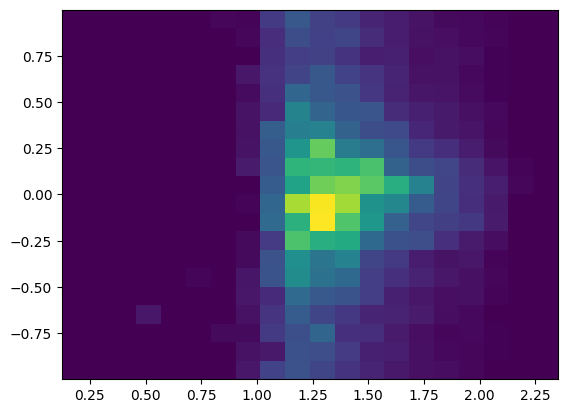

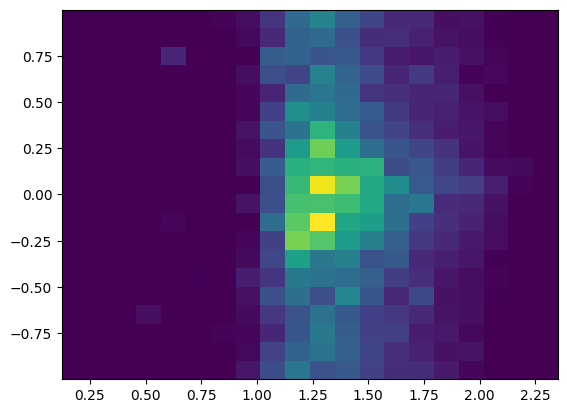

In [50]:
_ = plt.hist2d(np.log10(reco_energy[enrich_boolean]), reco_zen[enrich_boolean], bins=[x_edges, y_edges], weights=weight_no_osc[enrich_boolean])
plt.show()
#_ = plt.hist2d(np.log10(reco_energy_all), reco_zen_all, bins=[x_edges, y_edges], weights=weight_no_osc_all)

_ = plt.hist2d(np.log10(reco_energy_all[enrich_boolean_all]), reco_zen_all[enrich_boolean_all], bins=[x_edges, y_edges], weights=weight_no_osc_all[enrich_boolean_all])
plt.show()

_ = plt.hist2d(np.log10(reco_energy[enrich_boolean]), reco_zen[enrich_boolean], bins=[x_edges, y_edges], weights=weight_no_osc[enrich_boolean])
plt.show()
#_ = plt.hist2d(np.log10(reco_energy_all), reco_zen_all, bins=[x_edges, y_edges], weights=weight_no_osc_all)

_ = plt.hist2d(np.log10(reco_energy_all[enrich_boolean_all]), reco_zen_all[enrich_boolean_all], bins=[x_edges, y_edges], weights=weight_no_osc_all[enrich_boolean_all])
plt.show()

(array([5.88772044e-06, 6.69856735e-06, 9.68654152e-06, 1.47963633e-05,
        2.44457158e-05, 2.37138098e-05, 1.45396398e-05, 8.84569122e-06,
        6.03257544e-06, 6.04511744e-06]),
 array([-9.99878088e-01, -7.99961944e-01, -6.00045800e-01, -4.00129656e-01,
        -2.00213512e-01, -2.97368331e-04,  1.99618776e-01,  3.99534919e-01,
         5.99451063e-01,  7.99367207e-01,  9.99283351e-01]),
 <BarContainer object of 10 artists>)

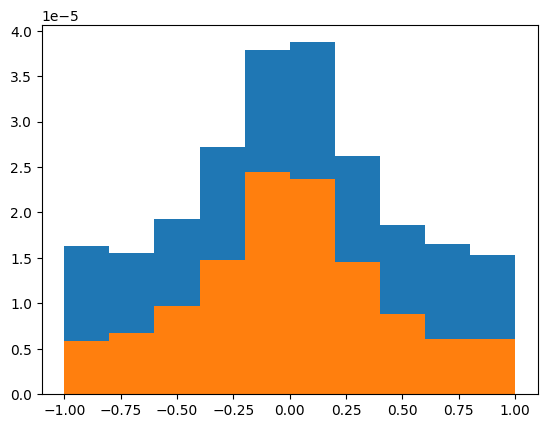

In [43]:
plt.hist(reco_zen_all[enrich_boolean_all], weights=weight_no_osc_all[enrich_boolean_all])
plt.hist(reco_zen[enrich_boolean], weights=weight_no_osc[enrich_boolean])

/tmp/ipykernel_467/2372976350.py:9: RuntimeWarning: invalid value encountered in divide
  plt.pcolormesh(x_edges, y_edges, hist/hist_all, cmap=plt.cm.BuPu)


Text(0.5, 1.0, 'Ratio')

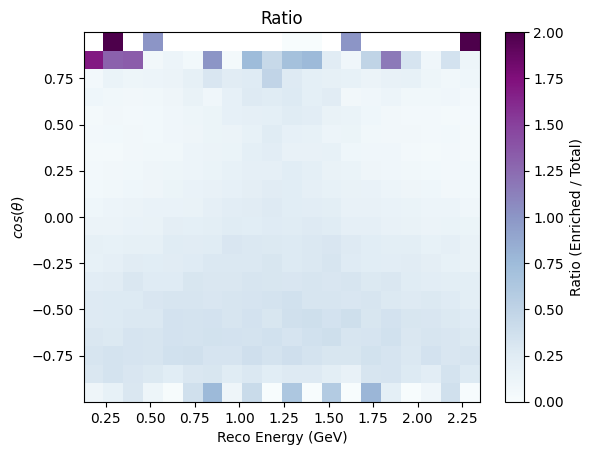

In [34]:
x_bins, y_bins = 20, 20
x_edges = np.linspace(min(np.log10(reco_energy_all)), max(np.log10(reco_energy_all)), x_bins + 1)
y_edges = np.linspace(min(reco_zen_all), max(reco_zen_all), y_bins + 1)

hist_all, _, _ = np.histogram2d(np.log10(reco_energy_all[~enrich_boolean_all]), reco_zen_all[~enrich_boolean_all], bins=[x_edges, y_edges], weights=weight_no_osc_all[~enrich_boolean_all])
hist, _, _ = np.histogram2d(np.log10(reco_energy[~enrich_boolean]), reco_zen[~enrich_boolean], bins=[x_edges, y_edges], weights=weight_no_osc[~enrich_boolean])

#plt.subplot(1, 2, 1)
plt.pcolormesh(x_edges, y_edges, hist/hist_all, cmap=plt.cm.BuPu)
plt.colorbar(label='Ratio (Enriched / Total)')
plt.xlabel('Reco Energy (GeV)')
plt.ylabel(r'$cos(\theta)$')
plt.title('Ratio')

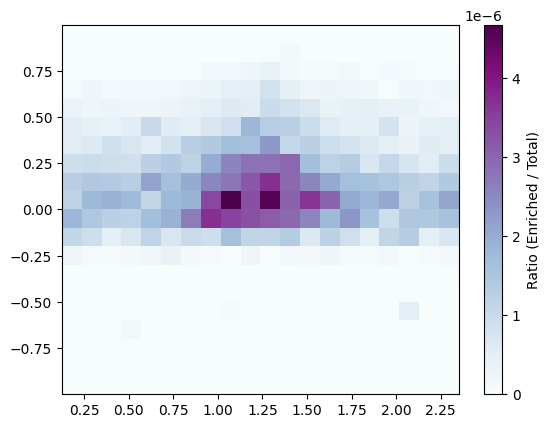

In [33]:
plt.pcolormesh(x_edges, y_edges, hist_all, cmap=plt.cm.BuPu)
plt.colorbar(label='Ratio (Enriched / Total)')

In [30]:
sum(weight)

0.00855423630240291

In [38]:
sum(weight)/(sum(weight_all) - sum(weight)), sum(weight_all), sum(weight_no_osc)/(sum(weight_no_osc_all) - sum(weight_no_osc)), sum(weight_no_osc_all)

(0.508445552949879,
 0.025378528014216074,
 0.4031830244355278,
 0.02977099341755968)

In [32]:
sum(weight), sum(weight_all)-sum(weight)

(0.00855423630240291, 0.016824291711813162)

(array([8.94220336e-07, 6.06091066e-06, 1.48193995e-05, 2.77012418e-05,
        3.32905303e-05, 3.77297896e-05, 4.21046295e-05, 4.22611207e-05,
        4.53436976e-05, 4.33582162e-05, 4.56739524e-05, 4.72229906e-05,
        5.04638204e-05, 5.58709194e-05, 5.86547302e-05, 6.56605869e-05,
        7.52739577e-05, 8.42632353e-05, 9.63517115e-05, 1.16251171e-04,
        1.29465291e-04, 1.54326742e-04, 1.81862468e-04, 1.90359374e-04,
        2.13774870e-04, 2.34768940e-04, 2.52182588e-04, 2.70739218e-04,
        2.66944806e-04, 2.85413839e-04, 3.02945176e-04, 2.74320221e-04,
        2.89486236e-04, 2.96223473e-04, 2.72441322e-04, 2.56640928e-04,
        2.66051826e-04, 2.47489827e-04, 2.34139028e-04, 2.24323304e-04,
        2.05494210e-04, 1.99629506e-04, 1.93691036e-04, 1.67631077e-04,
        1.56311919e-04, 1.50167769e-04, 1.32708018e-04, 1.21830444e-04,
        1.13599272e-04, 1.00749350e-04, 8.33465882e-05, 8.93921187e-05,
        8.02123316e-05, 6.43511113e-05, 6.82798614e-05, 5.509048

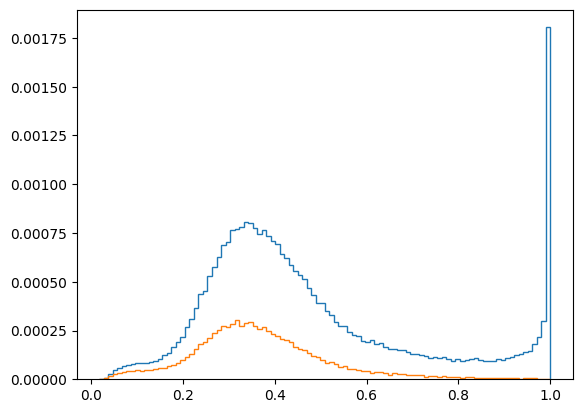

In [39]:
plt.hist(pid_all, bins=100, density=False, histtype='step', weights=weight_no_osc_all)
plt.hist(pid, bins=100, density=False, histtype='step', weights=weight_no_osc)

Text(0, 0.5, 'Reco $cos(\\theta)$')

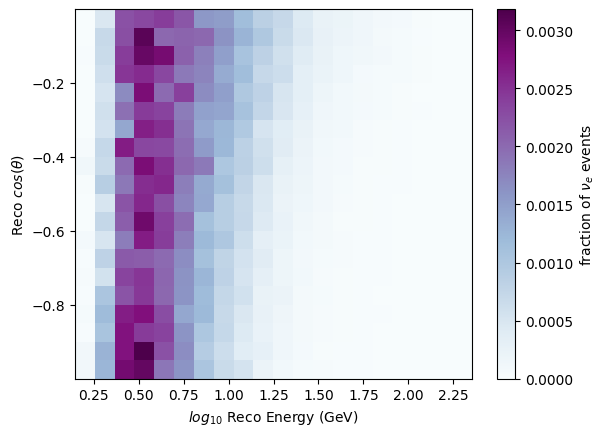

In [34]:
plt.hist2d(np.log10(reco_energy[reco_zen <= 0]), reco_zen[reco_zen <= 0], bins=20, cmap=plt.cm.BuPu, weights=weight_no_osc[reco_zen <= 0]/sum(weight_no_osc_all[reco_zen_all <= 0]))#, norm=LogNorm())
plt.colorbar(label=r'fraction of $\nu_e$ events')
plt.xlabel('$log_{10}$ Reco Energy (GeV)')
plt.ylabel(r'Reco $cos(\theta)$')

Text(0, 0.5, 'Reco $cos(\\theta)$')

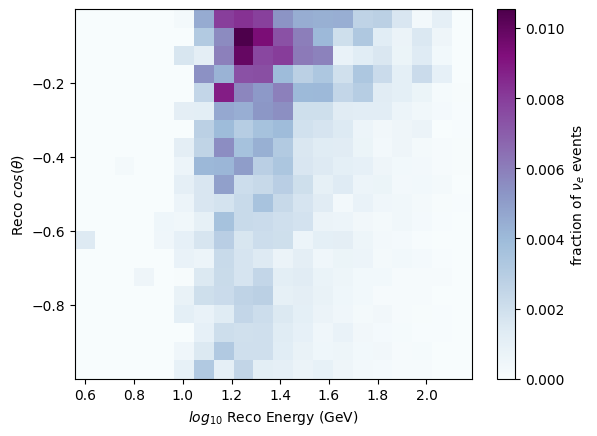

In [35]:
plt.hist2d(np.log10(reco_energy[enrich_boolean]), reco_zen[enrich_boolean], bins=20, cmap=plt.cm.BuPu, weights=weight_no_osc[enrich_boolean]/sum(weight_no_osc_all[enrich_boolean_all]))#, norm=LogNorm())
plt.colorbar(label=r'fraction of $\nu_e$ events')
plt.xlabel('$log_{10}$ Reco Energy (GeV)')
plt.ylabel(r'Reco $cos(\theta)$')

Text(0, 0.5, 'Reco $cos(\\theta)$')

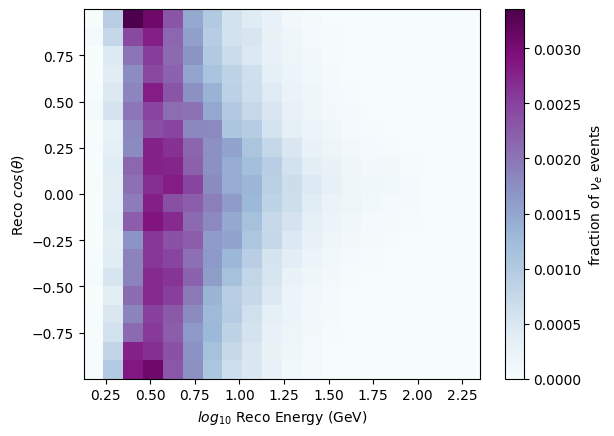

In [36]:
plt.hist2d(np.log10(reco_energy[~enrich_boolean]), reco_zen[~enrich_boolean], bins=20, cmap=plt.cm.BuPu, weights=weight_no_osc[~enrich_boolean]/sum(weight_no_osc_all[~enrich_boolean_all]))#, norm=LogNorm())
plt.colorbar(label=r'fraction of $\nu_e$ events')
plt.xlabel('$log_{10}$ Reco Energy (GeV)')
plt.ylabel(r'Reco $cos(\theta)$')

Text(0, 0.5, '$cos(\\theta)$')

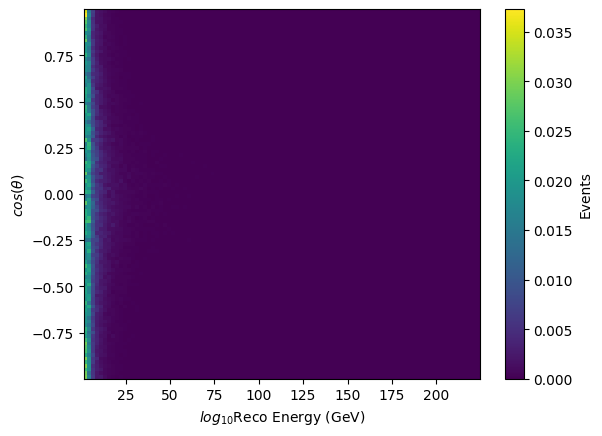

In [6]:
plt.hist2d(reco_energy, reco_zen, bins=100, weights=weight)
plt.colorbar(label='Events')
plt.xlabel('$log_{10} $Reco Energy (GeV)')
plt.ylabel(r'$cos(\theta)$')

Text(0, 0.5, 'Reco $cos(\\theta)$')

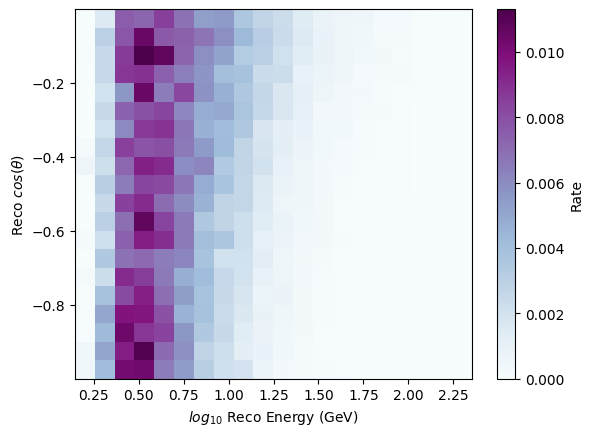

In [15]:
#from matplotlib.colors import LogNorm

plt.hist2d(np.log10(reco_energy[reco_zen <= 0]), reco_zen[reco_zen <= 0], bins=20, cmap=plt.cm.BuPu, weights=weight_no_osc[reco_zen <= 0]/sum(weight_no_osc[reco_zen <= 0]))#, norm=LogNorm())
plt.colorbar(label='Rate')
plt.xlabel('$log_{10}$ Reco Energy (GeV)')
plt.ylabel(r'Reco $cos(\theta)$')

Text(0, 0.5, 'Reco $cos(\\theta)$')

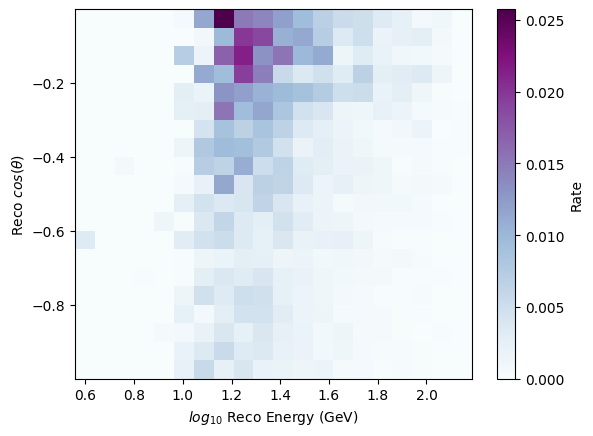

In [17]:
plt.hist2d(np.log10(reco_energy[enrich_boolean]), reco_zen[enrich_boolean], bins=20, cmap=plt.cm.BuPu, weights=weight_no_osc[enrich_boolean]/sum(weight_no_osc[enrich_boolean]))#, norm=LogNorm())
plt.colorbar(label='Rate')
plt.xlabel('$log_{10}$ Reco Energy (GeV)')
plt.ylabel(r'Reco $cos(\theta)$')

In [50]:
weight_no_osc

array([0., 0., 0., ..., 0., 0., 0.])

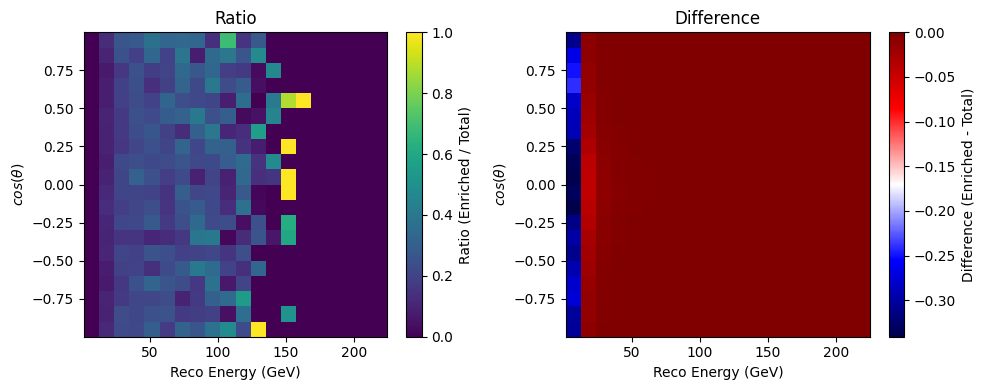

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Assume the following variables exist:
# reco_energy, reco_zen, enrich_boolean, weight_no_osc

# Define bin edges (same for both histograms)
x_bins = y_bins = 20
x_edges = np.linspace(min(reco_energy), max(reco_energy), x_bins + 1)
y_edges = np.linspace(min(reco_zen), max(reco_zen), y_bins + 1)

# Histogram 1: enriched sample
H_enriched, _, _ = np.histogram2d(
    reco_energy[enrich_boolean],
    reco_zen[enrich_boolean],
    bins=[x_edges, y_edges],
    weights=weight_no_osc[enrich_boolean]
)

# Histogram 2: full sample
H_total, _, _ = np.histogram2d(
    reco_energy,
    reco_zen,
    bins=[x_edges, y_edges],
    weights=weight_no_osc
)

# Ratio or difference
with np.errstate(divide='ignore', invalid='ignore'):
    ratio = np.true_divide(H_enriched, H_total)
    ratio[~np.isfinite(ratio)] = 0  # set inf/nan to 0

    diff = H_enriched - H_total

# Plot ratio
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.pcolormesh(x_edges, y_edges, ratio.T, cmap='viridis')
plt.colorbar(label='Ratio (Enriched / Total)')
plt.xlabel('Reco Energy (GeV)')
plt.ylabel(r'$cos(\theta)$')
plt.title('Ratio')

# Plot difference
plt.subplot(1, 2, 2)
plt.pcolormesh(x_edges, y_edges, diff.T, cmap='seismic')
plt.colorbar(label='Difference (Enriched - Total)')
plt.xlabel('Reco Energy (GeV)')
plt.ylabel(r'$cos(\theta)$')
plt.title('Difference')

plt.tight_layout()
plt.show()